# UCR time series — bond-dimension study

Figures built **straight from the analysis CSVs** under `analysis/outputs/{DATASET}/`. No
checkpoints are loaded — the trained models live on mathqi and only the post-hoc results were
transferred back. The raw time series *are* local, so §1.0 plots them directly.

- **Part 1** compares the analysed bond dimensions and shows the dataset itself.
- **Part 2** commits to one bond dimension (`BOND_DIM`, default **10**) and produces the alpha
  curves, defense bar plots, detection curves, the purification-radius comparison and the
  model-comparison tables.

| | |
|---|---|
| Data | `analysis/outputs/{dataset}/nat/legendre/d3r{R}c64/{seed_sweep_a0_DDMM, seed_sweep/cold_a{X}_DDMM}/` |
| Figures | `figures/ts/{dataset}/compare/` (Part 1) · `figures/ts/{dataset}/{arch}/` (Part 2) |
| Seeds | 10 per (bond dim, α) |
| Attack | PGD-$\infty$, $\varepsilon \in \{0.1, 0.2, 0.3\}$ absolute in $[-1,1]$ (= relative $\{0.05, 0.1, 0.15\}$) |
| Defenses | likelihood purification ($\delta \in \{0.2, 0.3\}$ absolute, = relative $\{0.1, 0.15\}$), likelihood detection ($q \in \{1,5,10,20\}\%$) |

**Not present in this data (yet):** Gibbs purification (`gibbs_data.csv` — `analysis/gibbs.py`
has not been run on these sweeps) and adversarial training (the `at` seed sweeps are configured
but never launched). Every cell below is data-driven: the Gibbs and AT parts stay in the
notebook and no-op on the empty frame, so they light up on their own once that data lands.

**Sampling is skipped** — nothing has been sampled from the TS models yet.

**Reporting unit.** Budgets are *authored* relative and the CSV columns are keyed that way, but
`REPORT_UNIT` in §0.2 controls what figures, tables and filenames **print**. It defaults to
`"abs"`. The conversion factor comes from each CSV's `range_size` column, so nothing assumes
legendre.

**Prerequisites**: `conda activate bm4tc`, launch Jupyter from the repo root, run top to bottom.

Change `DATASET` in §0.1 to switch dataset, `BOND_DIM` in §0.2 to switch the Part-2 commitment —
every figure path re-keys automatically.

---
# §0  Setup

In [1]:
import sys
from pathlib import Path

# This notebook lives in notebooks/; Jupyter's CWD is that folder. Walk up to the
# repo root (the dir containing src/) so all analysis/figures paths resolve.
PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / "src").is_dir() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))
print(f"PROJECT_ROOT = {PROJECT_ROOT}")

PROJECT_ROOT = /home/martin-lanigo/projects/bm4tc


In [2]:
import matplotlib

# Paper styling: Times New Roman via LaTeX (mathptmx). Requires a system LaTeX install
# (latex + dvipng); set USE_LATEX = False to fall back to matplotlib mathtext.
USE_LATEX = True
if USE_LATEX:
    matplotlib.rcParams.update({
        "text.usetex": True,
        "font.family": "serif",
        "font.serif": ["Times New Roman", "Times"],
        "text.latex.preamble": r"\usepackage{mathptmx}",
    })
else:
    matplotlib.rcParams.update({"text.usetex": False, "font.family": "sans-serif"})

# Shared type sizes for every figure below.
matplotlib.rcParams.update({
    "axes.labelsize": 15, "axes.titlesize": 15,
    "xtick.labelsize": 12, "ytick.labelsize": 12,
    "legend.fontsize": 11, "figure.dpi": 110, "savefig.dpi": 150,
})

# '%' must be escaped in BOTH engines: it is a comment char under usetex, and mathtext's
# parser rejects a bare '%' inside $...$. Always used inside math mode below.
PCT = r"\%"
print(f"USE_LATEX = {USE_LATEX}")

USE_LATEX = True


---
## §0.1  Dataset choice and registry

`DATASET` is the one switch that selects everything. The registry then scans

```
analysis/outputs/{DATASET}/{nat,at}/legendre/d{d}r{R}c{p}/
    seed_sweep_{α-token}_{DDMM}/          <- flat layout  (α=0 lives here)
    seed_sweep/{cold_}{α-token}_{DDMM}/   <- nested layout (α>0 lives here)
        evaluation_data.csv   one row per seed — acc, rob/{ε}, uq_* (detection + likelihood purification)
        gibbs_data.csv        one row per seed — gibbs_* (absent for the TS sweeps)
```

and builds two tidy long frames, `EVAL` and `GIBBS`, each keyed by
`(regime, arch, bond_dim, alpha)`.

Three things to know about this data:

1. **α is parsed from the directory name.** The `config/trainer.generative.criterion.kwargs.alpha`
   column is `NaN` in every one of these CSVs, so the `a0 / a001 / a01 / a02 / a05 / a1` token is
   the only source of truth. The `cold_` prefix (cold-start HPO) is stripped before the lookup.
2. **Both layouts are scanned**, and on a `(regime, arch, α)` collision the nested dir wins,
   then the later date. Today there are no collisions.
3. **`gibbs_data.csv` does not exist for these runs**, so `GIBBS` comes out empty. That is
   reported below, not treated as an error.

The coverage table reports **effective** seed counts (rows with a non-NaN value), so
partially-failed runs are visible rather than silently averaged away.

In [3]:
import re
import numpy as np
import pandas as pd

# ---- the dataset commitment ------------------------------------------------
DATASET = "ecg200"          # "ecg200" | "italypowerdemand" | any UCR set with analysis output
# ---------------------------------------------------------------------------
EMBEDDING = "legendre"

ANALYSIS_ROOT = PROJECT_ROOT / "analysis" / "outputs" / DATASET
FIG_ROOT = PROJECT_ROOT / "figures" / "ts" / DATASET

# Directory token -> alpha. The CSV's alpha config column is NaN, so this is authoritative.
ALPHA_TOKEN = {"a0": 0.0, "a001": 0.01, "a01": 0.1, "a02": 0.2, "a05": 0.5, "a1": 1.0}
ARCH_RE = re.compile(r"^d(\d+)r(\d+)(c\d+)?$")
DATE_RE = re.compile(r"_\d{4}(_\d{4})?$")          # trailing _DDMM or _DDMM_HHMM
PREFIX_RE = re.compile(r"^(seed_sweep_|cold_|warm_)+")


def _alpha_of(dirname):
    """('a001', 0.01) from 'cold_a001_2707' / 'seed_sweep_a0_2707'; (token, None) if unknown."""
    token = PREFIX_RE.sub("", DATE_RE.sub("", dirname))
    return token, ALPHA_TOKEN.get(token)


def _date_of(dirname):
    """Trailing date token, for tie-breaking. '' sorts first."""
    m = DATE_RE.search(dirname)
    return m.group(0) if m else ""


def discover():
    """[{regime, arch, bond_dim, alpha, dir}] for every seed-sweep run dir, both layouts."""
    found = {}
    for regime in ("nat", "at"):
        base = ANALYSIS_ROOT / regime / EMBEDDING
        if not base.is_dir():
            continue
        for arch_dir in sorted(base.iterdir()):
            m = ARCH_RE.match(arch_dir.name)
            if not m:
                continue
            # (candidate dir, layout rank) — nested wins over flat on a collision.
            cands = [(d, 1) for d in sorted((arch_dir / "seed_sweep").glob("*_*"))]
            cands += [(d, 0) for d in sorted(arch_dir.glob("seed_sweep_*")) if d.is_dir()]
            for run_dir, rank in cands:
                if not run_dir.is_dir():
                    continue
                _, alpha = _alpha_of(run_dir.name)
                if alpha is None:
                    continue
                key = (regime, arch_dir.name, alpha)
                prio = (rank, _date_of(run_dir.name))
                if key in found and found[key][0] >= prio:
                    continue
                found[key] = (prio, {"regime": regime, "arch": arch_dir.name,
                                     "bond_dim": int(m.group(2)), "alpha": alpha,
                                     "dir": run_dir})
    return [v[1] for _, v in sorted(found.items(), key=lambda kv: (kv[0][0], kv[0][1], kv[0][2]))]


RUNS = discover()
if not RUNS:
    raise FileNotFoundError(f"no analysed seed sweeps under {ANALYSIS_ROOT} — check DATASET")


def _stack(filename):
    """Concatenate one CSV kind across all runs, prefixed with the registry keys."""
    frames = []
    for r in RUNS:
        p = r["dir"] / filename
        if not p.exists():
            continue
        df = pd.read_csv(p)
        df = df.assign(regime=r["regime"], arch=r["arch"], bond_dim=r["bond_dim"],
                       alpha=r["alpha"], run_dir=str(r["dir"]))
        keys = ["regime", "arch", "bond_dim", "alpha", "run_dir"]
        frames.append(df[keys + [c for c in df.columns if c not in keys]])
    return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()


EVAL = _stack("evaluation_data.csv")
GIBBS = _stack("gibbs_data.csv")
HAVE_GIBBS = not GIBBS.empty

print(f"dataset   : {DATASET}")
print(f"{len(RUNS)} run dirs   EVAL {EVAL.shape}   GIBBS {GIBBS.shape}"
      f"{'' if HAVE_GIBBS else '   <- no gibbs_data.csv; Gibbs cells will no-op'}")
print(f"bond dims : {sorted(EVAL['bond_dim'].unique())}")
print(f"regimes   : {sorted(EVAL['regime'].unique())}"
      f"{'' if 'at' in set(EVAL['regime']) else '   <- no adversarially-trained runs'}\n")


def _n_valid(df, regime, arch, alpha, col):
    """Rows with a usable (non-NaN) value in `col`, or 0 if the frame/column is absent."""
    if df.empty or col not in df.columns:
        return 0
    m = (df["regime"] == regime) & (df["arch"] == arch) & (df["alpha"] == alpha)
    return int(pd.to_numeric(df.loc[m, col], errors="coerce").notna().sum())


rows = [{"arch": r["arch"], "regime": r["regime"], "alpha": r["alpha"],
         "eval": _n_valid(EVAL, r["regime"], r["arch"], r["alpha"], "acc"),
         "gibbs": _n_valid(GIBBS, r["regime"], r["arch"], r["alpha"], "gibbs_clean_acc"),
         "dir": r["dir"].name} for r in RUNS]
COVERAGE = pd.DataFrame(rows).sort_values(["arch", "regime", "alpha"]).reset_index(drop=True)
N_SEEDS = int(COVERAGE["eval"].max())

print(f"Coverage (effective seed counts, '.' = CSV absent; max = {N_SEEDS} seeds):")
print(COVERAGE.to_string(index=False, formatters={
    "eval": lambda v: "." if v == 0 else str(v),
    "gibbs": lambda v: "." if v == 0 else str(v)}))

_gaps = COVERAGE[COVERAGE["eval"] < N_SEEDS]
print(f"\n{len(_gaps)} incomplete cell(s) — these show as gaps in the figures below:")
for _, g in _gaps.iterrows():
    print(f"  {g['regime']:>3} {g['arch']} a={g['alpha']:<5} eval={g['eval']}")

dataset   : ecg200
12 run dirs   EVAL (120, 125)   GIBBS (0, 0)   <- no gibbs_data.csv; Gibbs cells will no-op
bond dims : [10, 20]
regimes   : ['nat']   <- no adversarially-trained runs

Coverage (effective seed counts, '.' = CSV absent; max = 10 seeds):
    arch regime  alpha eval gibbs                dir
d3r10c64    nat   0.00   10     . seed_sweep_a0_2707
d3r10c64    nat   0.01   10     .     cold_a001_2707
d3r10c64    nat   0.10   10     .      cold_a01_2707
d3r10c64    nat   0.20   10     .      cold_a02_2707
d3r10c64    nat   0.50   10     .      cold_a05_2707
d3r10c64    nat   1.00   10     .       cold_a1_2707
d3r20c64    nat   0.00   10     . seed_sweep_a0_2707
d3r20c64    nat   0.01   10     .     cold_a001_2707
d3r20c64    nat   0.10   10     .      cold_a01_2707
d3r20c64    nat   0.20   10     .      cold_a02_2707
d3r20c64    nat   0.50   10     .      cold_a05_2707
d3r20c64    nat   1.00   10     .       cold_a1_2707

0 incomplete cell(s) — these show as gaps in the figur

---
## §0.2  Configuration

`BOND_DIM` is the Part-2 commitment. Everything downstream — figure directories included —
re-keys off it. The model ladder, the bond dimensions and the α grid are all read back out of
the registry rather than hardcoded, so a newly analysed α or an AT sweep appears without an edit.

In [4]:
import matplotlib.pyplot as plt

# ---- the Part-2 commitment -------------------------------------------------
BOND_DIM = 10
# ---------------------------------------------------------------------------

EPS_LIST = [0.05, 0.1, 0.15]   # PGD budgets present in the CSVs (relative)
EPS_MAIN = 0.1                 # headline budget for single-epsilon figures
PURIFY_RADIUS = "0.15"         # likelihood-purification radius, relative
PURIFY_RADII = ["0.1", "0.15"] # both radii present; compared in §2.5
GIBBS_KS = [1, 3, 6]           # Gibbs sweep counts, if gibbs_data.csv ever lands
GIBBS_K = 6
GIBBS_N_EVAL = 250             # Gibbs subsample size — for captions
DET_PCT = "10pct"              # headline detection threshold (10th pct of clean log p(x))
PERCENTILES = [1, 5, 10, 20]   # detection thresholds present in the CSVs

# --- REPORTING UNIT ------------------------------------------------------------------
# Budgets are authored RELATIVE (fractions of the input domain width `hi - lo`). This
# switch controls DISPLAY ONLY -- labels, titles, table cells and figure filenames.
# Column lookups always use the relative token, so the data path never changes with it.
REPORT_UNIT = "abs"          # "rel" | "abs"

assert (EVAL["eps_unit"].dropna() == "rel").all(), \
    "CSV is not relative-keyed -- run tools/migrate_metric_keys.py"
_rs = EVAL["range_size"].dropna().unique()
assert len(_rs) == 1, f"mixed range_size in one study: {_rs}"
RANGE_SIZE = float(_rs[0])   # 2.0 legendre, 1.0 fourier -- read from data, not assumed


def bstr(rel):
    """Budget as it should be PRINTED, per REPORT_UNIT. Never used for column lookups."""
    return f"{float(rel) * RANGE_SIZE if REPORT_UNIT == 'abs' else float(rel):g}"


EPS_MAIN_D = bstr(EPS_MAIN)             # display forms of the headline budgets
PURIFY_RADIUS_D = bstr(PURIFY_RADIUS)
# -------------------------------------------------------------------------------------

# ---- everything below is read out of the registry --------------------------
BOND_DIMS = sorted(EVAL["bond_dim"].unique())
NAT_ALPHAS = sorted(EVAL.loc[EVAL["regime"] == "nat", "alpha"].unique())
AT_ALPHAS = sorted(EVAL.loc[EVAL["regime"] == "at", "alpha"].unique())
ARCH = next(a for a in sorted(EVAL["arch"].unique())
            if int(ARCH_RE.match(a).group(2)) == BOND_DIM)

# Canonical model order: the nat alpha ladder, then any adversarially-trained models.
MODEL_ORDER = [("nat", a) for a in NAT_ALPHAS] + [("at", a) for a in AT_ALPHAS]


def alpha_str(a):
    """Compact alpha label: 0, 0.01, 0.5, 1."""
    return f"{a:g}"


def model_label(regime, alpha, tex=True):
    a = alpha_str(alpha)
    if not tex:
        return f"a={a}" if regime == "nat" else f"AT a={a}"
    return rf"$\alpha{{=}}{a}$" if regime == "nat" else rf"AT ($\alpha{{=}}{a}$)"


# Colours: the nat ladder walks viridis in alpha order; AT models get warm accents.
MODEL_COLOR = {("nat", a): tuple(c) for a, c in
               zip(NAT_ALPHAS, plt.cm.viridis(np.linspace(0.05, 0.88, max(len(NAT_ALPHAS), 1))))}
MODEL_COLOR.update({("at", a): c for a, c in
                    zip(AT_ALPHAS, ["#D32F2F", "#7B1FA2", "#00838F", "#EF6C00"])})

BOND_COLOR = dict(zip(BOND_DIMS, ["#1f77b4", "#ff7f0e", "#2ca02c", "#9467bd"]))
EPS_COLOR = {0.05: "steelblue", 0.1: "darkorange", 0.15: "seagreen"}

print(f"Part 2 arch = {ARCH}  (bond dims available: {BOND_DIMS})")
print(f"nat alphas  = {[alpha_str(a) for a in NAT_ALPHAS]}")
print(f"at  alphas  = {[alpha_str(a) for a in AT_ALPHAS] or 'none'}")
print(f"eps={EPS_LIST} main={EPS_MAIN}  radii={PURIFY_RADII} main={PURIFY_RADIUS}")
print(f"reporting unit = {REPORT_UNIT!r} (range size {RANGE_SIZE}) -> "
      f"eps shown as {[bstr(e) for e in EPS_LIST]}, radius as {PURIFY_RADIUS_D}")
print(f"figures -> {FIG_ROOT.relative_to(PROJECT_ROOT)}")


def _suffixes(df, prefix, part=-1):
    """Distinct trailing path components of the `prefix...` columns actually in the CSVs."""
    if df.empty:
        return []
    return sorted({c.split("/")[part] for c in df.columns if c.startswith(prefix)})


# Guard the headline constants against the data, so a bad default fails loudly here rather
# than silently emitting empty lines and blank bars further down.
_have_eps = _suffixes(EVAL, "rob/", part=1)
_have_rad = _suffixes(EVAL, "uq_purify_acc/")
_have_k = _suffixes(GIBBS, "gibbs_purify_acc/")
print(f"\nin the CSVs: eps={_have_eps}  purify radii={_have_rad}  gibbs k={_have_k or 'none'}")
for name, val, have in (("EPS_MAIN", str(EPS_MAIN), _have_eps),
                        ("PURIFY_RADIUS", PURIFY_RADIUS, _have_rad)):
    flag = "OK " if val in have else "!! "
    print(f"  {flag}{name} = {val}" + ("" if val in have else f"  <-- NOT PRESENT, pick from {have}"))
if HAVE_GIBBS and str(GIBBS_K) not in _have_k:
    print(f"  !! GIBBS_K = {GIBBS_K}  <-- NOT PRESENT, pick from {_have_k}")

Part 2 arch = d3r10c64  (bond dims available: [10, 20])
nat alphas  = ['0', '0.01', '0.1', '0.2', '0.5', '1']
at  alphas  = none
eps=[0.05, 0.1, 0.15] main=0.1  radii=['0.1', '0.15'] main=0.15
figures -> figures/ts/ecg200

in the CSVs: eps=['0.05', '0.1', '0.15']  purify radii=['0.1', '0.15']  gibbs k=none
  OK EPS_MAIN = 0.1
  OK PURIFY_RADIUS = 0.15


---
## §0.3  Shared helpers

Selection, aggregation, figure paths, and the two curve builders used repeatedly below.

**`accept_curve`** deserves a note — it is the basis of the accept-rate figures (§1.3, §2.4a):

- **x** = ratio of passed samples = $1 - $ `uq_detection/{q}pct/{eps}`
- **y** = accuracy on passed samples = $1 - $ `uq_det_err_passed/{q}pct/{eps}`

Both are measured **on the adversarial set**: `uq_detection` is the fraction of *adversarial*
inputs whose $\log p(x)$ falls below the threshold $\tau_q$ (itself the $q$-th percentile of
*clean* $\log p(x)$), and `uq_det_err_passed` is the misclassification rate among the survivors.
The passed ratio is therefore **not** simply $1 - q/100$, and the curve traces a genuine
trade-off rather than a reparametrisation of $q$. The $q=0$ point (accept everything) is
anchored at $(1.0,\ $`uq_adv_acc/{eps}`$)$.

In [5]:
def sel(df, regime=None, arch=None, alpha=None, bond_dim=None):
    """Row subset of EVAL/GIBBS matching the given registry keys."""
    if df.empty:
        return df
    m = pd.Series(True, index=df.index)
    for key, val in (("regime", regime), ("arch", arch),
                     ("alpha", alpha), ("bond_dim", bond_dim)):
        if val is not None:
            m &= df[key] == val
    return df[m]


def ms(df, col, flip=False):
    """(mean, std) over seeds, NaN-dropping. (nan, nan) if the frame/column is unusable."""
    if df is None or df.empty or col not in df.columns:
        return float("nan"), float("nan")
    v = pd.to_numeric(df[col], errors="coerce").dropna()
    if len(v) == 0:
        return float("nan"), float("nan")
    if flip:
        v = 1.0 - v
    return float(v.mean()), float(v.std() if len(v) > 1 else 0.0)


_EPS_IN_NAME = re.compile(r"(eps)(\d*\.?\d+)")


def _drop_stale_twin(path):
    """Delete this same output written under the other REPORT_UNIT.

    Exact paths only, and never a name this run also produces -- rel 0.05 renders as
    abs 0.1, which is rel 0.1's own name, so a blind swap would delete a live file.
    """
    m = _EPS_IN_NAME.search(path.name)
    if not m:
        return
    shown = float(m.group(2))
    rel = shown / RANGE_SIZE if REPORT_UNIT == "abs" else shown
    other = f"{rel if REPORT_UNIT == 'abs' else rel * RANGE_SIZE:g}"
    if f"eps{other}" in {f"eps{bstr(e)}" for e in EPS_LIST}:
        return
    twin = path.with_name(_EPS_IN_NAME.sub(rf"\g<1>{other}", path.name))
    if twin != path and twin.exists():
        twin.unlink()
        print(f"  removed stale {twin.name}")


def fig_path(group, name, arch=None):
    """figures/ts/{DATASET}/{arch or 'compare'}/{group}/{name}, parents created."""
    d = FIG_ROOT / (arch if arch else "compare") / group
    d.mkdir(parents=True, exist_ok=True)
    p = d / name
    _drop_stale_twin(p)
    return p


def save(fig, path):
    fig.savefig(path, bbox_inches="tight")
    plt.show()
    print(f"Saved {path.relative_to(PROJECT_ROOT)}")


def setup_alpha_axis(ax):
    """Symlog alpha axis ticked at the trained alphas."""
    ax.set_xscale("symlog", linthresh=5e-3)
    ax.set_xlim(-2e-4, 1.3)
    ax.set_xticks(NAT_ALPHAS)
    ax.set_xticklabels([alpha_str(a) for a in NAT_ALPHAS], rotation=45, ha="right")
    ax.xaxis.set_minor_locator(matplotlib.ticker.NullLocator())
    ax.set_xlabel(r"$\alpha$")


def accept_curve(df, eps):
    """(q, passed_ratio, acc_on_passed, xerr, yerr) over q in [0] + PERCENTILES.

    x = 1 - uq_detection/{q}pct/{eps}       fraction of adversarial inputs NOT flagged
    y = 1 - uq_det_err_passed/{q}pct/{eps}  accuracy among those that passed
    q = 0 (accept everything) anchors at (1.0, uq_adv_acc/{eps}).
    Points stay in q order, which is monotone decreasing in x.
    """
    qs, xs, ys, xe, ye = [], [], [], [], []
    m, s = ms(df, f"uq_adv_acc/{eps}")
    if not np.isnan(m):
        qs.append(0); xs.append(1.0); ys.append(m); xe.append(0.0); ye.append(s)
    for q in PERCENTILES:
        cd, cp = f"uq_detection/{q}pct/{eps}", f"uq_det_err_passed/{q}pct/{eps}"
        xm, xs_ = ms(df, cd, flip=True)
        ym, ys_ = ms(df, cp, flip=True)
        if np.isnan(xm) or np.isnan(ym):
            continue
        qs.append(q); xs.append(xm); ys.append(ym); xe.append(xs_); ye.append(ys_)
    return (np.array(qs), np.array(xs), np.array(ys),
            np.nan_to_num(np.array(xe)), np.nan_to_num(np.array(ye)))


def gibbs_curve(df, eps=None):
    """(k, mean, std) over k in [0] + GIBBS_KS. k=0 is the paired undefended anchor.

    eps=None gives the clean-input curve (what purification costs when nothing attacked).
    """
    ks, mm, ss = [], [], []
    for k in [0] + GIBBS_KS:
        if eps is None:
            col = "gibbs_clean_acc" if k == 0 else f"gibbs_clean_purify_acc/{k}"
        else:
            col = f"gibbs_adv_acc/{eps}" if k == 0 else f"gibbs_purify_acc/{eps}/{k}"
        m, s = ms(df, col)
        if np.isnan(m):
            continue
        ks.append(k); mm.append(m); ss.append(s)
    return np.array(ks), np.array(mm), np.nan_to_num(np.array(ss))


def errline(ax, x, y, s, color, label=None, ls="-", marker="o"):
    """Line + 1-std band, skipping empty series."""
    if len(x) == 0:
        return
    ax.plot(x, y, color=color, ls=ls, lw=1.8, marker=marker, ms=5, label=label)
    ax.fill_between(x, np.asarray(y) - s, np.asarray(y) + s, color=color, alpha=0.15)


def tex_cell(m, s, bold=False, signed=False):
    if np.isnan(m):
        return "---"
    num = f"{m:+.3f}" if signed else f"{m:.3f}"
    body = f"{num} \\pm {s:.3f}" if (not np.isnan(s) and s != 0.0) else num
    return f"$\\mathbf{{{body}}}$" if bold else f"${body}$"


def txt_cell(m, s, best=False, signed=False):
    if np.isnan(m):
        return "---"
    num = f"{m:+.3f}" if signed else f"{m:.3f}"
    return (f"{num}±{s:.3f}" if (not np.isnan(s) and s != 0.0) else num) + ("*" if best else "")


def strip_tex(t):
    """Crude LaTeX -> plain, for the .txt previews."""
    for a, b in ((r"\ ", " "), (r"\%", "%"), ("$", ""), ("{=}", "="), (r"\alpha", "a"),
                 (r"\varepsilon", "eps"), (r"\mathbf", ""), (r"\times", "x"),
                 ("{", ""), ("}", "")):
        t = t.replace(a, b)
    return t


def best_index(col_means):
    """Index of the largest non-NaN mean (all metrics here are higher-is-better)."""
    valid = [(v, i) for i, v in enumerate(col_means) if not np.isnan(v)]
    return max(valid)[1] if valid else -1


print("helpers ready")

helpers ready


---
## §0.4  Reproduction commands

The trained checkpoints are **not local** — `run_path` in every CSV points at
`/mathqi/mnissen/bm4tc/outputs/...`. This notebook never loads a model; it reads the CSVs and
(in §1.0) the raw UCR TSVs. The cell below prints the commands that produced this data, for the
record.

In [6]:
print("# Training — 3-stage alpha-HPO pipeline, run from the project root:")
for R in BOND_DIMS:
    a = f"{DATASET}/nat/{EMBEDDING}/d3r{R}c64"
    print(f"python -m experiments.train --multirun +experiments={a}/seed_sweep_a0")
    print(f"python -m experiments.train --multirun +experiments={a}/seed_sweep/cold_a{{001,01,02,05,1}}")
print("#   (lr / soft_strength in those configs come from the cold-start HPO studies")
print(f"#    {DATASET}/nat/{EMBEDDING}/hpo/cold.yaml, filled per (arch, alpha).)")

print("\n# Post-hoc analysis — one pass per run dir:")
print("python analysis/sweep.py <sweep_dir>          # -> evaluation_data.csv")
print(f"python analysis/gibbs.py <sweep_dir> --sweeps {','.join(map(str, GIBBS_KS))} "
      f"--n-eval {GIBBS_N_EVAL}   # -> gibbs_data.csv  (NOT yet run for these sweeps)")

# Training — 3-stage alpha-HPO pipeline, run from the project root:
python -m experiments.train --multirun +experiments=ecg200/nat/legendre/d3r10c64/seed_sweep_a0
python -m experiments.train --multirun +experiments=ecg200/nat/legendre/d3r10c64/seed_sweep/cold_a{001,01,02,05,1}
python -m experiments.train --multirun +experiments=ecg200/nat/legendre/d3r20c64/seed_sweep_a0
python -m experiments.train --multirun +experiments=ecg200/nat/legendre/d3r20c64/seed_sweep/cold_a{001,01,02,05,1}
#   (lr / soft_strength in those configs come from the cold-start HPO studies
#    ecg200/nat/legendre/hpo/cold.yaml, filled per (arch, alpha).)

# Post-hoc analysis — one pass per run dir:
python analysis/sweep.py <sweep_dir>          # -> evaluation_data.csv
python analysis/gibbs.py <sweep_dir> --sweeps 1,3,6 --n-eval 250   # -> gibbs_data.csv  (NOT yet run for these sweeps)


---
---
# Part 1 — the dataset, and the bond-dimension comparison

Figures here span **every** analysed bond dimension and land in
`figures/ts/{DATASET}/compare/`. The question this part answers is *which bond dimension to
commit to* in Part 2.

## §1.0  The dataset itself

Per-class trace density from the raw UCR TSVs in `.datasets/ucr_ts/{Canonical}/` (train + test
pooled, as `analysis/visualize/ts_datasets.py` does), with the class mean overlaid. This is the
*unscaled* data — training applies a min-max scaler into the embedding range, which is a
per-feature affine map and so does not change the shape of these curves.

This section replaces the sampling grid the MNIST notebook shows: nothing has been sampled from
the TS models yet, so what is plotted is the real data the models were fit to.

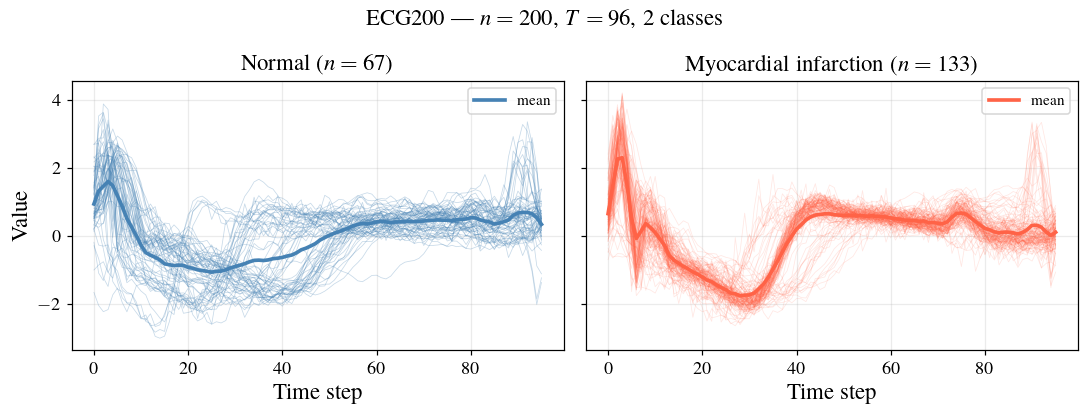

Saved figures/ts/ecg200/compare/dataset/traces_by_class.pdf


In [7]:
UCR_TS_ROOT = PROJECT_ROOT / ".datasets" / "ucr_ts"

# Human-readable class names; anything else falls back to "class {i}".
CLASS_NAMES = {
    "ecg200": ["Normal", "Myocardial infarction"],
    "italypowerdemand": ["Oct--Mar", "Apr--Sep"],
}
TRACE_COLORS = ["steelblue", "tomato", "seagreen", "darkorange", "purple", "sienna"]


def canonical_folder(dataset):
    """Case-insensitive match of the config name against the downloaded UCR folders."""
    if not UCR_TS_ROOT.is_dir():
        return None
    by_lower = {d.name.lower(): d for d in UCR_TS_ROOT.iterdir() if d.is_dir()}
    return by_lower.get(dataset.lower())


def load_ucr(folder):
    """Train + test TSVs pooled; labels remapped to 0-indexed ints. -> (X, t)."""
    raw = np.vstack([np.loadtxt(folder / f"{folder.name}_TRAIN.tsv"),
                     np.loadtxt(folder / f"{folder.name}_TEST.tsv")])
    labels_raw, X = raw[:, 0], raw[:, 1:]
    label_map = {v: i for i, v in enumerate(sorted(np.unique(labels_raw)))}
    return X, np.array([label_map[v] for v in labels_raw], dtype=int)


_folder = canonical_folder(DATASET)
if _folder is None:
    print(f"raw TSVs not found under {UCR_TS_ROOT} — skipping the data figure "
          f"(run a training job once to trigger the download)")
else:
    X, t = load_ucr(_folder)
    classes = sorted(np.unique(t))
    names = CLASS_NAMES.get(DATASET, [f"class {i}" for i in classes])
    steps = np.arange(X.shape[1])

    fig, axes = plt.subplots(1, len(classes), figsize=(5.0 * len(classes), 3.8),
                             sharey=True, squeeze=False)
    for ax, c in zip(axes[0], classes):
        Xc = X[t == c]
        color = TRACE_COLORS[c % len(TRACE_COLORS)]
        # Scale alpha so dense classes don't wash out.
        a = max(0.03, min(0.4, 20.0 / max(len(Xc), 1)))
        for row in Xc:
            ax.plot(steps, row, color=color, alpha=a, lw=0.5)
        ax.plot(steps, Xc.mean(0), color=color, lw=2.4, label="mean")
        ax.set_title(rf"{names[c]}  ($n={len(Xc)}$)")
        ax.set_xlabel("Time step")
        ax.grid(True, alpha=0.25)
        ax.legend(loc="best", fontsize=10)
    axes[0][0].set_ylabel("Value")
    fig.suptitle(rf"{_folder.name} — $n={len(X)}$, $T={X.shape[1]}$, "
                 rf"{len(classes)} classes", fontsize=15)
    fig.tight_layout()
    save(fig, fig_path("dataset", "traces_by_class.pdf"))

## §1.1  Every headline metric vs bond dimension

Panels at $\varepsilon = $ `EPS_MAIN`, one line per model, mean $\pm$ 1 std over seeds:

| panel | column |
|---|---|
| Clean | `acc` |
| Rob. (undefended) | `rob/{eps}` |
| Purif. (lk.) | `uq_purify_acc/{eps}/{PURIFY_RADIUS}` |
| Purif. (Gibbs) | `gibbs_purify_acc/{eps}/{GIBBS_K}` — *only if `gibbs_data.csv` exists* |

Missing points are genuine coverage gaps (see the §0.1 table), not plotting failures.

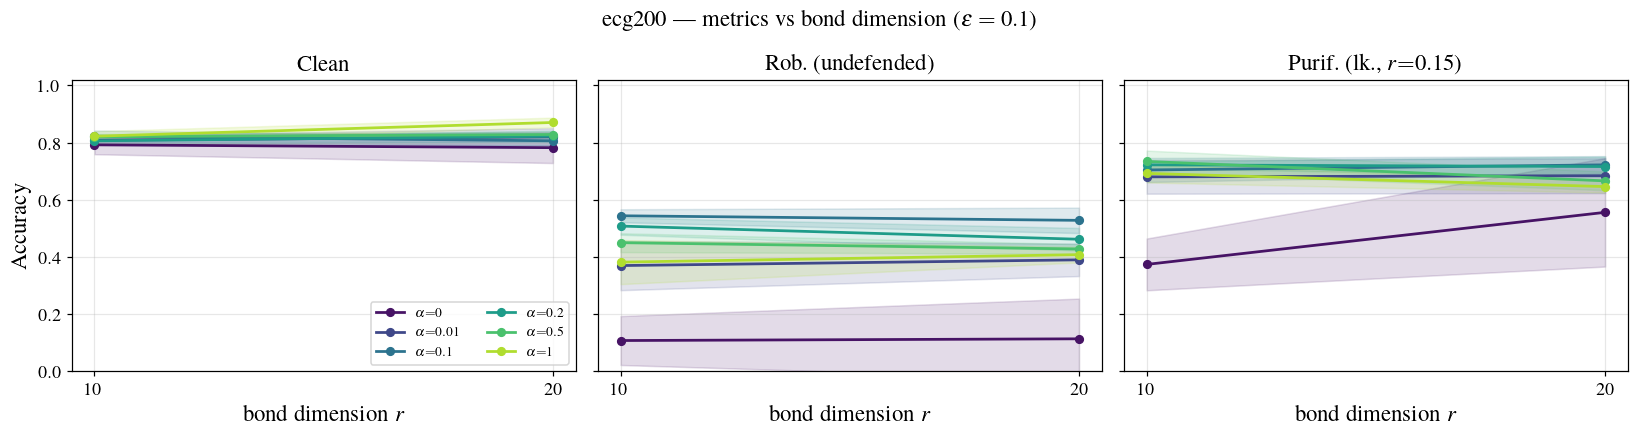

Saved figures/ts/ecg200/compare/bonddim/metric_vs_bonddim.pdf


In [8]:
PANELS = [
    ("Clean",                             EVAL,  "acc",                                        False),
    (r"Rob.\ (undefended)" if USE_LATEX else "Rob. (undefended)",
                                          EVAL,  f"rob/{EPS_MAIN}",                            False),
    (rf"Purif.\ (lk., $r{{=}}{PURIFY_RADIUS_D}$)" if USE_LATEX else "Purif. (lk.)",
                                          EVAL,  f"uq_purify_acc/{EPS_MAIN}/{PURIFY_RADIUS}",  False),
]
if HAVE_GIBBS:
    PANELS.append((rf"Purif.\ (Gibbs, $k{{=}}{GIBBS_K}$)" if USE_LATEX else "Purif. (Gibbs)",
                   GIBBS, f"gibbs_purify_acc/{EPS_MAIN}/{GIBBS_K}", True))

# <=3 panels go in one row, so every panel keeps its own x tick labels; 4 falls back to 2x2.
ncol = len(PANELS) if len(PANELS) <= 3 else 2
nrow = int(np.ceil(len(PANELS) / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(5.0 * ncol, 4.0 * nrow),
                         sharex=True, sharey=True, squeeze=False)
for ax, (title, src, col, is_gibbs) in zip(axes.ravel(), PANELS):
    for regime, alpha in MODEL_ORDER:
        pts = [(bd, *ms(sel(src, regime=regime, bond_dim=bd, alpha=alpha), col))
               for bd in BOND_DIMS]
        pts = [(b, m, s) for b, m, s in pts if not np.isnan(m)]
        if not pts:
            continue
        b, m, s = map(np.array, zip(*pts))
        errline(ax, b, m, s, MODEL_COLOR[(regime, alpha)], model_label(regime, alpha))
    ax.set_title(title)
    ax.set_xscale("log"); ax.set_xticks(BOND_DIMS)
    ax.set_xticklabels([str(b) for b in BOND_DIMS])
    ax.xaxis.set_minor_locator(matplotlib.ticker.NullLocator())
    ax.set_ylim(0, 1.02); ax.grid(True, alpha=0.3)
    if is_gibbs:
        ax.text(0.03, 0.04, rf"$n_{{\mathrm{{eval}}}}={GIBBS_N_EVAL}$", transform=ax.transAxes,
                fontsize=10, color="dimgray")
for ax in axes.ravel()[len(PANELS):]:
    ax.axis("off")
for ax in axes[-1, :]:
    ax.set_xlabel("bond dimension $r$")
for ax in axes[:, 0]:
    ax.set_ylabel("Accuracy")
axes[0, 0].legend(ncol=2, fontsize=9, loc="lower right")
fig.suptitle(rf"{DATASET} — metrics vs bond dimension ($\varepsilon={EPS_MAIN_D}$)", fontsize=15)
fig.tight_layout()
save(fig, fig_path("bonddim", "metric_vs_bonddim.pdf"))

## §1.2  Alpha curve, one line per bond dimension

The same alpha ladder drawn once per bond dimension — clean accuracy (left) against undefended
robustness (right) at $\varepsilon = $ `EPS_MAIN`. This is the figure to read when choosing
`BOND_DIM`: it shows whether the clean/robust trade-off across $\alpha$ has the same shape at
every bond dimension, or whether capacity changes the story. Dotted horizontal lines are the
AT reference at the matching bond dimension, drawn only where an AT run exists.

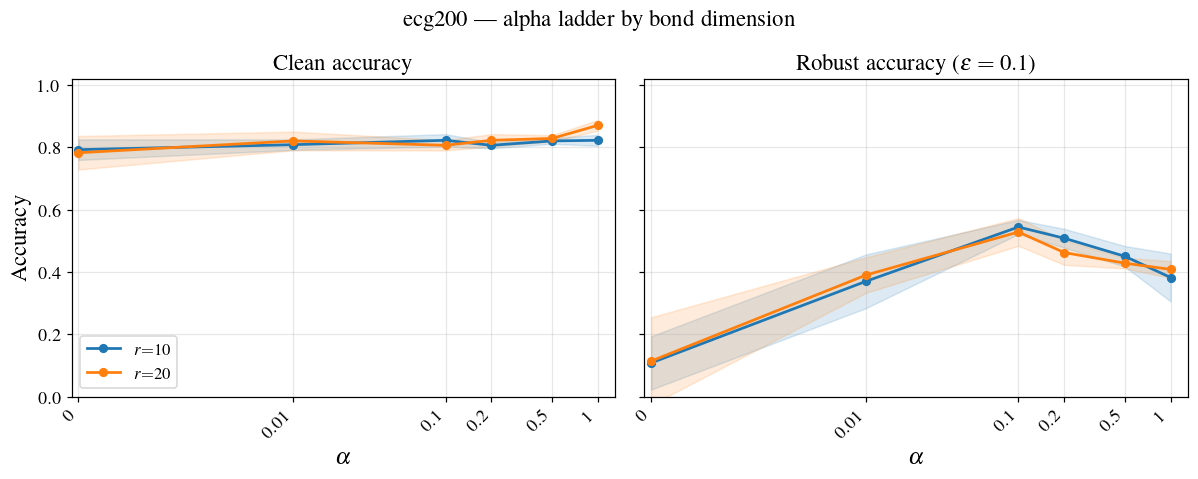

Saved figures/ts/ecg200/compare/bonddim/alpha_curve_by_bonddim.pdf


In [9]:
fig, (ax_l, ax_r) = plt.subplots(1, 2, figsize=(11, 4.4), sharey=True)
for bd in BOND_DIMS:
    c = BOND_COLOR[bd]
    for ax, col in ((ax_l, "acc"), (ax_r, f"rob/{EPS_MAIN}")):
        pts = [(a, *ms(sel(EVAL, regime="nat", bond_dim=bd, alpha=a), col)) for a in NAT_ALPHAS]
        pts = [(a, m, s) for a, m, s in pts if not np.isnan(m)]
        if not pts:
            continue
        a, m, s = map(np.array, zip(*pts))
        errline(ax, a, m, s, c, rf"$r{{=}}{bd}$")
    # AT reference at this bond dim (alpha-independent): horizontal dotted line.
    for at_a in AT_ALPHAS:
        m, _ = ms(sel(EVAL, regime="at", bond_dim=bd, alpha=at_a), f"rob/{EPS_MAIN}")
        if not np.isnan(m):
            ax_r.axhline(m, color=c, ls=":", lw=1.4, alpha=0.8)

for ax, title in ((ax_l, "Clean accuracy"),
                  (ax_r, rf"Robust accuracy ($\varepsilon={EPS_MAIN_D}$)")):
    setup_alpha_axis(ax); ax.set_title(title)
    ax.set_ylim(0, 1.02); ax.grid(True, alpha=0.3)
ax_l.set_ylabel("Accuracy")
ax_l.legend(loc="lower left")
if AT_ALPHAS:
    ax_r.plot([], [], color="gray", ls=":", lw=1.4, label="AT (same $r$)")
    ax_r.legend(loc="upper left")
fig.suptitle(f"{DATASET} — alpha ladder by bond dimension", fontsize=15)
fig.tight_layout()
save(fig, fig_path("bonddim", "alpha_curve_by_bonddim.pdf"))

## §1.3  Accuracy on passed samples vs ratio of passed samples

**x** = ratio of passed samples $= 1 - $ detection rate · **y** = accuracy among those passed.
One marker per rejection threshold $q \in \{0, 1, 5, 10, 20\}\%$, joined in $q$ order
(increasing $q$ moves left: more adversarial inputs are flagged, fewer pass). Error bars are
1 std over seeds in **both** axes. Rows are models, columns are attack budgets, one line per
bond dimension; only the two extreme operating points are labelled, to keep the panels legible.

Read it as an operating-point curve: the top-right corner is ideal — keep everything and still
be accurate. A curve that rises steeply as it moves left means the detector is buying real
accuracy per sample discarded; a flat curve means it is discarding samples for nothing.

**y is shared per row, not globally** — the models sit at very different accuracy levels, so one
shared scale would flatten most panels into a line.

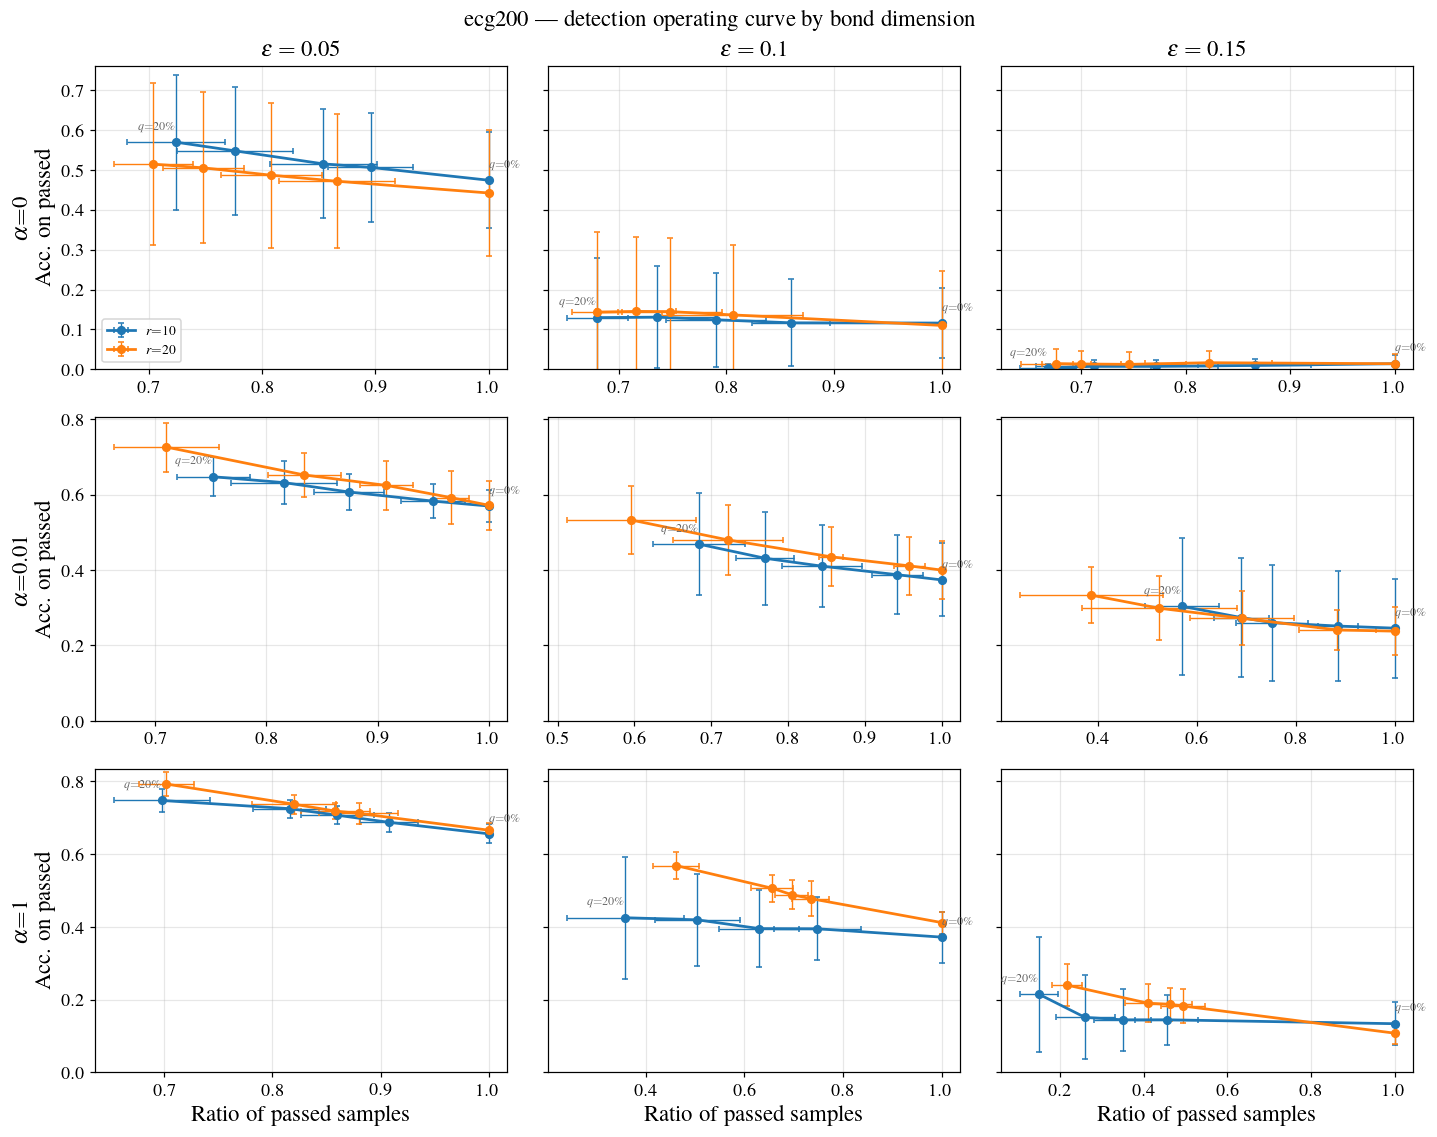

Saved figures/ts/ecg200/compare/bonddim/accept_curve_by_bonddim.pdf


In [10]:
# The extremes of the ladder plus one interior point, or whatever subset exists.
_pick = [a for a in (NAT_ALPHAS[0], 0.01, NAT_ALPHAS[-1]) if a in NAT_ALPHAS]
ACC_MODELS = [("nat", a) for a in dict.fromkeys(_pick)] + [("at", a) for a in AT_ALPHAS[:1]]


def label_endpoints(ax, q, x, y):
    """Label only the two extreme operating points; x is monotone decreasing in q."""
    if len(q) < 2:
        return
    for idx, ha in ((0, "left"), (len(q) - 1, "right")):
        ax.annotate(rf"$q{{=}}{int(q[idx])}{PCT}$", (x[idx], y[idx]),
                    textcoords="offset points", xytext=(0, 8), ha=ha,
                    fontsize=8, color="dimgray")


fig, axes = plt.subplots(len(ACC_MODELS), len(EPS_LIST),
                         figsize=(4.4 * len(EPS_LIST), 3.5 * len(ACC_MODELS)),
                         sharey="row", squeeze=False)
for row, (regime, alpha) in enumerate(ACC_MODELS):
    for col, eps in enumerate(EPS_LIST):
        ax = axes[row][col]
        for i, bd in enumerate(BOND_DIMS):
            q, x, y, xe, ye = accept_curve(sel(EVAL, regime=regime, bond_dim=bd, alpha=alpha),
                                           eps)
            if len(x) == 0:
                continue
            ax.errorbar(x, y, xerr=xe, yerr=ye, color=BOND_COLOR[bd], lw=1.8, marker="o",
                        ms=5, capsize=2, elinewidth=0.9, label=rf"$r{{=}}{bd}$")
            if i == 0:
                label_endpoints(ax, q, x, y)
        ax.grid(True, alpha=0.3)
        ax.set_ylim(bottom=0)
        ax.margins(y=0.22)
        if row == 0:
            ax.set_title(rf"$\varepsilon={bstr(eps)}$")
        if row == len(ACC_MODELS) - 1:
            ax.set_xlabel("Ratio of passed samples")
    axes[row][0].set_ylabel(model_label(regime, alpha) + "\nAcc. on passed")
axes[0][0].legend(fontsize=9, loc="lower left")
fig.suptitle(f"{DATASET} — detection operating curve by bond dimension", fontsize=15)
fig.tight_layout()
save(fig, fig_path("bonddim", "accept_curve_by_bonddim.pdf"))

## §1.4  Training losses vs bond dimension

Discriminative NLL (`dis_loss`, left axis) and generative NLL (`gen_loss`, right axis) against
bond dimension, one line per $\alpha$. The two axes differ by orders of magnitude — the
generative NLL is a $T$-dimensional log-density, the discriminative one a per-class log-loss.

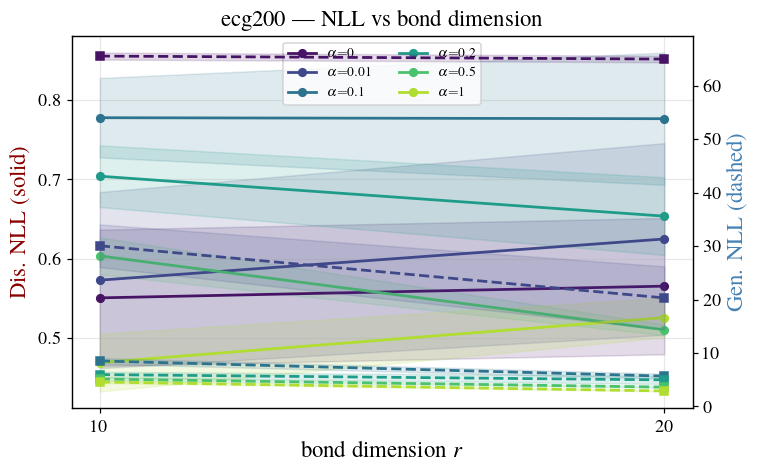

Saved figures/ts/ecg200/compare/bonddim/nll_vs_bonddim.pdf


In [11]:
fig, ax_l = plt.subplots(figsize=(7, 4.4))
ax_r = ax_l.twinx()
for alpha in NAT_ALPHAS:
    c = MODEL_COLOR[("nat", alpha)]
    for ax, col, ls in ((ax_l, "dis_loss", "-"), (ax_r, "gen_loss", "--")):
        pts = [(bd, *ms(sel(EVAL, regime="nat", bond_dim=bd, alpha=alpha), col))
               for bd in BOND_DIMS]
        pts = [(b, m, s) for b, m, s in pts if not np.isnan(m)]
        if not pts:
            continue
        b, m, s = map(np.array, zip(*pts))
        lab = model_label("nat", alpha) if ax is ax_l else None
        errline(ax, b, m, s, c, lab, ls=ls, marker="o" if ax is ax_l else "s")

ax_l.set_xscale("log"); ax_l.set_xticks(BOND_DIMS)
ax_l.set_xticklabels([str(b) for b in BOND_DIMS])
ax_l.xaxis.set_minor_locator(matplotlib.ticker.NullLocator())
ax_l.set_xlabel("bond dimension $r$")
ax_l.set_ylabel("Dis. NLL (solid)", color="darkred")
ax_r.set_ylabel("Gen. NLL (dashed)", color="steelblue")
ax_l.grid(True, alpha=0.3)
ax_l.legend(ncol=2, fontsize=9, loc="best")
ax_l.set_title(f"{DATASET} — NLL vs bond dimension")
fig.tight_layout()
save(fig, fig_path("bonddim", "nll_vs_bonddim.pdf"))

## §1.5  Cross-bond-dimension summary table

Rows are (bond dimension × model), columns the headline metrics at $\varepsilon = $ `EPS_MAIN`.
Best per column in **bold**. Written as booktabs `.tex` (needs `\usepackage{booktabs,multirow}`)
and an aligned `.txt` preview.

In [12]:
# (header, source frame, column, flip)
SUMMARY_METRICS = [
    ("Clean",                                            EVAL,  "acc", False),
    (r"Rob.",                                            EVAL,  f"rob/{EPS_MAIN}", False),
    (rf"Purif.\ (lk., $r{{=}}{PURIFY_RADIUS_D}$)",       EVAL,  f"uq_purify_acc/{EPS_MAIN}/{PURIFY_RADIUS}", False),
    (rf"Acc.\ passed ($q{{=}}10\%$)",                    EVAL,  f"uq_det_err_passed/{DET_PCT}/{EPS_MAIN}", True),
]
if HAVE_GIBBS:
    SUMMARY_METRICS.insert(3, (rf"Purif.\ (Gibbs, $k{{=}}{GIBBS_K}$)", GIBBS,
                               f"gibbs_purify_acc/{EPS_MAIN}/{GIBBS_K}", False))

body = []          # [(row_label_tex, row_label_txt, bond_dim, [(mean, std), ...])]
for bd in BOND_DIMS:
    for regime, alpha in MODEL_ORDER:
        cells = [ms(sel(src, regime=regime, bond_dim=bd, alpha=alpha), col, flip)
                 for _, src, col, flip in SUMMARY_METRICS]
        if all(np.isnan(m) for m, _ in cells):
            continue
        body.append((model_label(regime, alpha), model_label(regime, alpha, tex=False),
                     bd, cells))

best = [best_index([r[3][j][0] for r in body]) for j in range(len(SUMMARY_METRICS))]

L = [r"\begin{tabular}{@{}ll" + "r" * len(SUMMARY_METRICS) + r"@{}}", r"\toprule",
     r"$r$ & Model & " + " & ".join(h for h, *_ in SUMMARY_METRICS) + r" \\", r"\midrule"]
prev_bd = None
for i, (lab, _, bd, cells) in enumerate(body):
    if bd != prev_bd:
        if prev_bd is not None:
            L.append(r"\cmidrule(lr){1-%d}" % (2 + len(SUMMARY_METRICS)))
        n = sum(1 for r in body if r[2] == bd)
        first = f"\\multirow{{{n}}}{{*}}{{{bd}}}"
        prev_bd = bd
    else:
        first = ""
    L.append(f"{first} & {lab} & " +
             " & ".join(tex_cell(m, s, bold=(best[j] == i)) for j, (m, s) in enumerate(cells)) +
             r" \\")
L += [r"\bottomrule", r"\end{tabular}"]

W = 20
hdr = f"{'r':<5}{'Model':<12}" + "".join(f"{strip_tex(h):<{W}}" for h, *_ in SUMMARY_METRICS)
P = [f"{DATASET} — summary at eps={EPS_MAIN_D} (lk. radius {PURIFY_RADIUS_D}"
     + (f", Gibbs k={GIBBS_K} on n_eval={GIBBS_N_EVAL}" if HAVE_GIBBS else "")
     + f"), {N_SEEDS} seeds; * = best",
     hdr, "-" * len(hdr)]
prev_bd = None
for i, (_, lab, bd, cells) in enumerate(body):
    if bd != prev_bd and prev_bd is not None:
        P.append("-" * len(hdr))
    P.append(f"{(str(bd) if bd != prev_bd else ''):<5}{lab:<12}" +
             "".join(f"{txt_cell(m, s, best=(best[j] == i)):<{W}}"
                     for j, (m, s) in enumerate(cells)))
    prev_bd = bd

fig_path("tables", "bonddim_summary.tex").write_text("\n".join(L) + "\n")
fig_path("tables", "bonddim_summary.txt").write_text("\n".join(P) + "\n")
print(f"Saved {fig_path('tables', 'bonddim_summary.tex').relative_to(PROJECT_ROOT)} and .txt\n")
print("\n".join(P))

Saved figures/ts/ecg200/compare/tables/bonddim_summary.tex and .txt

ecg200 — summary at eps=0.1 (lk. radius 0.15), 10 seeds; * = best
r    Model       Clean               Rob.                Purif. (lk., r=0.15)Acc. passed (q=10%) 
-------------------------------------------------------------------------------------------------
10   a=0         0.792±0.033         0.108±0.085         0.374±0.090         0.131±0.128         
     a=0.01      0.808±0.017         0.370±0.086         0.680±0.059         0.431±0.124         
     a=0.1       0.822±0.020         0.544±0.023*        0.704±0.042         0.581±0.065         
     a=0.2       0.806±0.010         0.508±0.030         0.722±0.011         0.554±0.054         
     a=0.5       0.820±0.009         0.450±0.033         0.734±0.038*        0.485±0.075         
     a=1         0.822±0.018         0.382±0.077         0.692±0.032         0.420±0.127         
---------------------------------------------------------------------------------

---
---
# Part 2 — Committed bond dimension

Everything below is for **`BOND_DIM`** (set in §0.2, default 10) and lands in
`figures/ts/{DATASET}/{ARCH}/`. Change `BOND_DIM` and re-run from §0.2 to regenerate the whole
part at another bond dimension.

In [13]:
print(f"Part 2 — arch = {ARCH}  (bond dim {BOND_DIM})")
print(f"figures -> {(FIG_ROOT / ARCH).relative_to(PROJECT_ROOT)}")
_present = [(r, a) for r, a in MODEL_ORDER
            if not sel(EVAL, regime=r, arch=ARCH, alpha=a).empty]
_gibbs_present = [(r, a) for r, a in MODEL_ORDER
                  if not sel(GIBBS, regime=r, arch=ARCH, alpha=a).empty]
print(f"models with eval  : {[model_label(r, a, tex=False) for r, a in _present]}")
print(f"models with gibbs : {[model_label(r, a, tex=False) for r, a in _gibbs_present] or 'none'}")

Part 2 — arch = d3r10c64  (bond dim 10)
figures -> figures/ts/ecg200/d3r10c64
models with eval  : ['a=0', 'a=0.01', 'a=0.1', 'a=0.2', 'a=0.5', 'a=1']
models with gibbs : none


## §2.1  Alpha curve — accuracy

Every defense against $\alpha$ at $\varepsilon = $ `EPS_MAIN`, mean $\pm$ 1 std over seeds:
clean accuracy, undefended robustness, and likelihood purification at **both** radii (plus Gibbs
at $k = $ `GIBBS_K` if that data exists). An adversarially-trained model is $\alpha$-independent
and would be drawn as a horizontal reference band — none exist for this dataset yet.

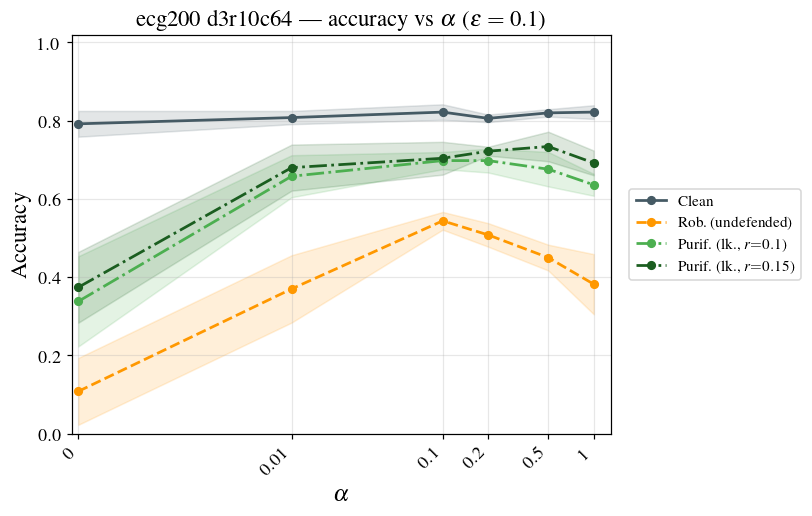

Saved figures/ts/ecg200/d3r10c64/alpha/alpha_curve_accuracy.pdf


In [14]:
CURVES = [
    ("Clean",                                    EVAL,  "acc",                                       "#455A64", "-"),
    (r"Rob.\ (undefended)" if USE_LATEX else "Rob. (undefended)",
                                                 EVAL,  f"rob/{EPS_MAIN}",                           "#FF9800", "--"),
]
RADIUS_COLOR = {"0.1": "#4CAF50", "0.15": "#1B5E20"}
for r_ in PURIFY_RADII:
    CURVES.append((rf"Purif.\ (lk., $r{{=}}{bstr(r_)}$)" if USE_LATEX else f"Purif. (lk., r={bstr(r_)})",
                   EVAL, f"uq_purify_acc/{EPS_MAIN}/{r_}", RADIUS_COLOR.get(r_, "#4CAF50"), "-."))
if HAVE_GIBBS:
    CURVES.append((rf"Purif.\ (Gibbs, $k{{=}}{GIBBS_K}$)" if USE_LATEX else f"Purif. (Gibbs, k={GIBBS_K})",
                   GIBBS, f"gibbs_purify_acc/{EPS_MAIN}/{GIBBS_K}", "#7B1FA2", ":"))

fig, ax = plt.subplots(figsize=(7.5, 4.8))
for label, src, col, color, ls in CURVES:
    pts = [(a, *ms(sel(src, regime="nat", arch=ARCH, alpha=a), col)) for a in NAT_ALPHAS]
    pts = [(a, m, s) for a, m, s in pts if not np.isnan(m)]
    if not pts:
        print(f"skip (no data): {strip_tex(label)}")
        continue
    a, m, s = map(np.array, zip(*pts))
    errline(ax, a, m, s, color, label, ls=ls)

for at_a, c in zip(AT_ALPHAS, ["#D32F2F", "#7B1FA2"]):
    m, s = ms(sel(EVAL, regime="at", arch=ARCH, alpha=at_a), f"rob/{EPS_MAIN}")
    if np.isnan(m):
        continue
    ax.axhline(m, color=c, ls="--", lw=1.5, label=rf"AT ($\alpha{{=}}{alpha_str(at_a)}$) rob.")
    ax.axhspan(m - s, m + s, color=c, alpha=0.12)

setup_alpha_axis(ax)
ax.set_ylabel("Accuracy"); ax.set_ylim(0, 1.02); ax.grid(True, alpha=0.3)
ax.set_title(rf"{DATASET} {ARCH} — accuracy vs $\alpha$ ($\varepsilon={EPS_MAIN_D}$)")
ax.legend(fontsize=10, loc="center left", bbox_to_anchor=(1.02, 0.5))
fig.tight_layout()
save(fig, fig_path("alpha", "alpha_curve_accuracy.pdf", arch=ARCH))

## §2.2  Alpha curve — NLL

Discriminative and generative NLL against $\alpha$ on separate axes. This is the trade-off the
mixed objective is interpolating: raising $\alpha$ buys density modelling at the cost of
class-conditional sharpness.

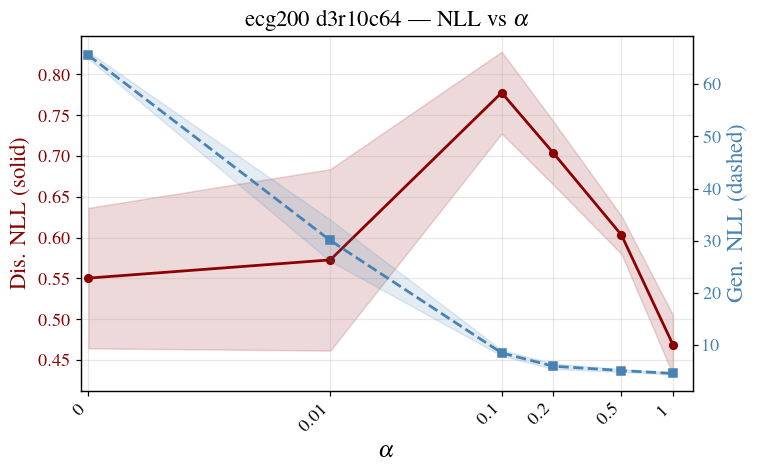

Saved figures/ts/ecg200/d3r10c64/alpha/alpha_curve_nll.pdf


In [15]:
fig, ax_l = plt.subplots(figsize=(7, 4.4))
ax_r = ax_l.twinx()
for ax, col, color, ls, mk in ((ax_l, "dis_loss", "darkred", "-", "o"),
                               (ax_r, "gen_loss", "steelblue", "--", "s")):
    pts = [(a, *ms(sel(EVAL, regime="nat", arch=ARCH, alpha=a), col)) for a in NAT_ALPHAS]
    pts = [(a, m, s) for a, m, s in pts if not np.isnan(m)]
    if not pts:
        continue
    a, m, s = map(np.array, zip(*pts))
    errline(ax, a, m, s, color, col, ls=ls, marker=mk)

setup_alpha_axis(ax_l)
ax_l.set_ylabel("Dis. NLL (solid)", color="darkred")
ax_r.set_ylabel("Gen. NLL (dashed)", color="steelblue")
ax_l.tick_params(axis="y", labelcolor="darkred")
ax_r.tick_params(axis="y", labelcolor="steelblue")
ax_l.grid(True, alpha=0.3)
ax_l.set_title(rf"{DATASET} {ARCH} — NLL vs $\alpha$")
fig.tight_layout()
save(fig, fig_path("alpha", "alpha_curve_nll.pdf", arch=ARCH))

## §2.3  Defense comparison bar plot

One standalone file per attack budget ($\varepsilon$ in the filename). x = model, bar groups =
defense, mean $\pm$ 1 std over seeds:

- **Clean** — clean accuracy reference (`acc`, $\varepsilon$-independent)
- **Rob.** — undefended adversarial accuracy (`rob/{eps}`)
- **Purif. (lk.)** — likelihood purification at radius `PURIFY_RADIUS`
- **Purif. (Gibbs)** — Gibbs purification at $k = $ `GIBBS_K`, *if that data exists*
- **Accept** — accuracy on inputs the detector does not flag, $1-$`uq_det_err_passed/10pct/{eps}`

Note **Accept** is an accuracy *conditional on passing*, so it is not directly comparable to the
unconditional bars beside it — §2.4 shows what fraction of samples that conditioning keeps.

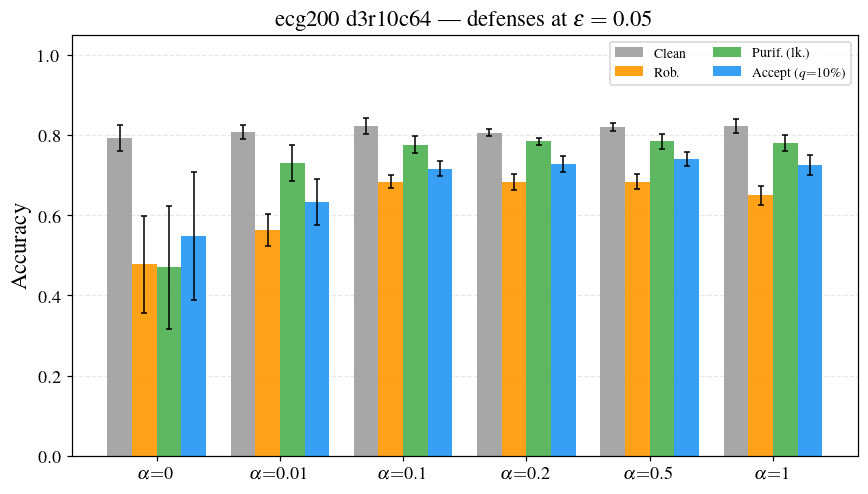

Saved figures/ts/ecg200/d3r10c64/robustness/defense_comparison_eps0.05.pdf


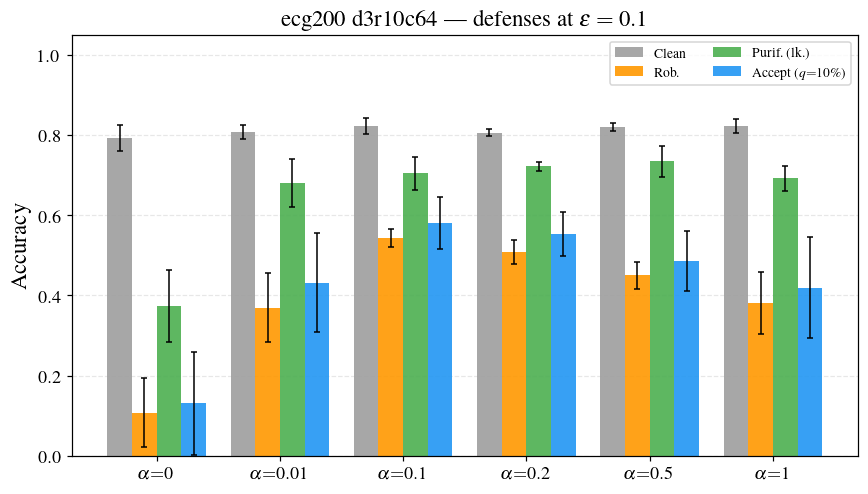

Saved figures/ts/ecg200/d3r10c64/robustness/defense_comparison_eps0.1.pdf


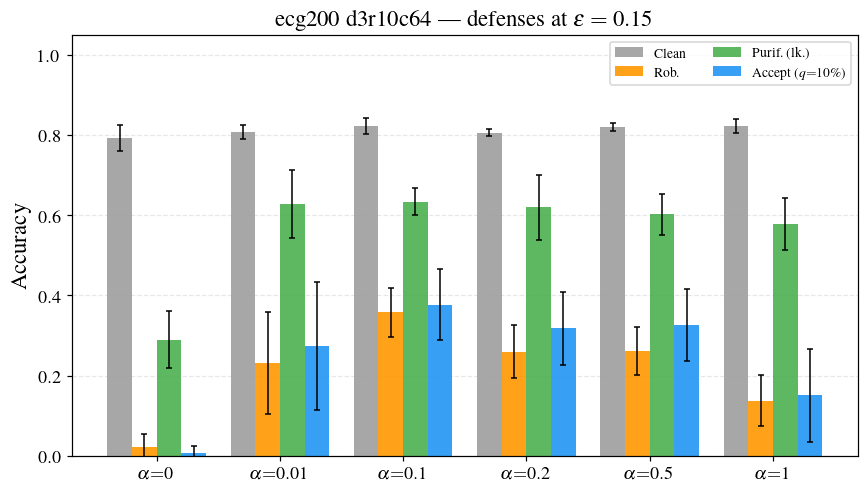

Saved figures/ts/ecg200/d3r10c64/robustness/defense_comparison_eps0.15.pdf


In [16]:
DEFENSES = [
    ("Clean",                                    "#9E9E9E", EVAL,  "acc",                                       False),
    ("Rob.",                                     "#FF9800", EVAL,  "rob/{eps}",                                 False),
    (r"Purif.\ (lk.)" if USE_LATEX else "Purif. (lk.)",
                                                 "#4CAF50", EVAL,  f"uq_purify_acc/{{eps}}/{PURIFY_RADIUS}",    False),
    (rf"Accept ($q{{=}}10{PCT}$)",               "#2196F3", EVAL,  f"uq_det_err_passed/{DET_PCT}/{{eps}}",      True),
]
if HAVE_GIBBS:
    DEFENSES.insert(3, (rf"Purif.\ (Gibbs $k{{=}}{GIBBS_K}$)" if USE_LATEX else f"Purif. (Gibbs k={GIBBS_K})",
                        "#7B1FA2", GIBBS, f"gibbs_purify_acc/{{eps}}/{GIBBS_K}", False))

models = [(r, a) for r, a in MODEL_ORDER if not sel(EVAL, regime=r, arch=ARCH, alpha=a).empty]
x, n_d = np.arange(len(models)), len(DEFENSES)
width = 0.8 / n_d

for eps in EPS_LIST:
    fig, ax = plt.subplots(figsize=(8.0, 4.6))
    for j, (label, color, src, tmpl, flip) in enumerate(DEFENSES):
        stats = [ms(sel(src, regime=r, arch=ARCH, alpha=a), tmpl.format(eps=eps), flip)
                 for r, a in models]
        m, s = zip(*stats)
        ax.bar(x + (j - (n_d - 1) / 2) * width, np.nan_to_num(m), width,
               yerr=np.nan_to_num(s), label=label, color=color, capsize=2, alpha=0.9,
               error_kw={"elinewidth": 1})
    ax.set_xticks(x)
    ax.set_xticklabels([model_label(r, a) for r, a in models])
    ax.set_ylabel("Accuracy"); ax.set_ylim(0, 1.05)
    ax.grid(axis="y", alpha=0.3, ls="--"); ax.set_axisbelow(True)
    ax.set_title(rf"{DATASET} {ARCH} — defenses at $\varepsilon={bstr(eps)}$")
    ax.legend(fontsize=9, ncol=2, loc="upper right")
    fig.tight_layout()
    save(fig, fig_path("robustness", f"defense_comparison_eps{bstr(eps)}.pdf", arch=ARCH))

## §2.4  Detection — what rejection actually buys

Two views of the same likelihood detector at the committed bond dimension.

**§2.4a — operating curve.** Accuracy on passed samples against the ratio of passed samples
(the §1.3 axes), one line per model, one panel per $\varepsilon$. This answers *what does
rejecting $q\%$ buy* — the further a curve sits toward the top-right, the better the detector
separates adversarial from clean inputs for that model. Here $y$ *is* shared across panels: the
spread between models is the point, and it survives the common scale.

**§2.4b — threshold view.** The same quantities against $q$ itself, one figure per model:
accuracy on accepted on the left axis (solid, ○) and detection rate on the right (dashed, ■),
one colour per $\varepsilon$. This answers *which $q$ to pick*.

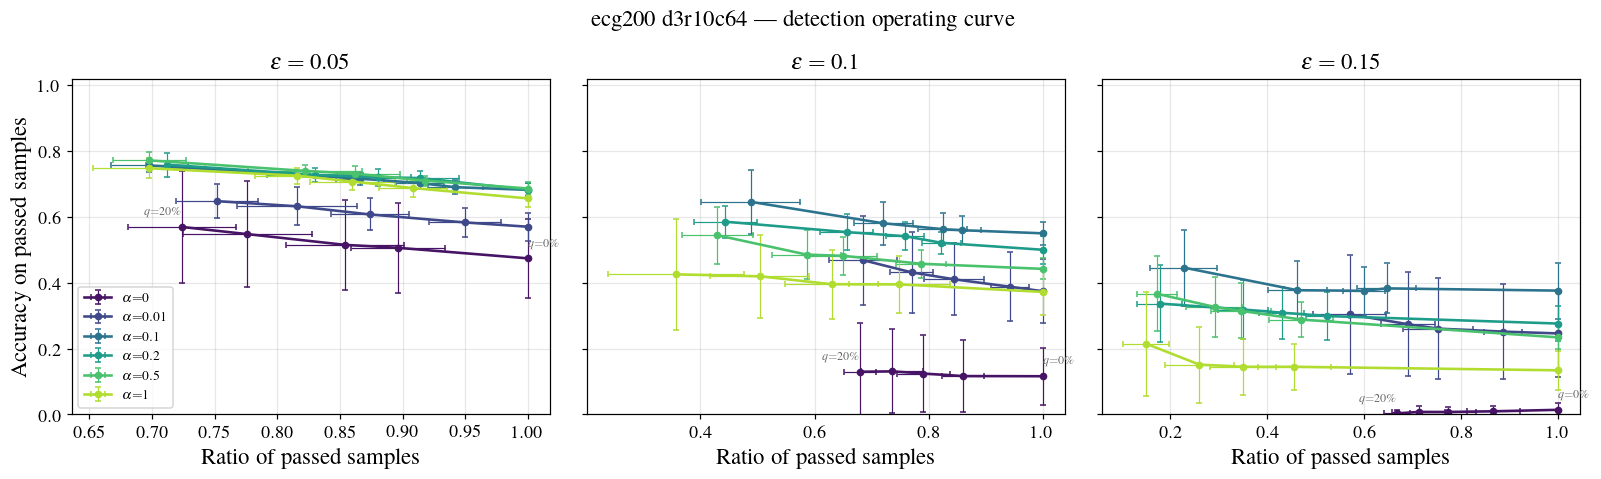

Saved figures/ts/ecg200/d3r10c64/detection/accept_acc_vs_passed_ratio.pdf


In [17]:
models = [(r, a) for r, a in MODEL_ORDER if not sel(EVAL, regime=r, arch=ARCH, alpha=a).empty]

fig, axes = plt.subplots(1, len(EPS_LIST), figsize=(4.9 * len(EPS_LIST), 4.4),
                         sharey=True, squeeze=False)
for ax, eps in zip(axes[0], EPS_LIST):
    for i, (regime, alpha) in enumerate(models):
        q, x, y, xe, ye = accept_curve(sel(EVAL, regime=regime, arch=ARCH, alpha=alpha), eps)
        if len(x) == 0:
            continue
        ax.errorbar(x, y, xerr=xe, yerr=ye, color=MODEL_COLOR[(regime, alpha)], lw=1.7,
                    marker="o", ms=4, capsize=2, elinewidth=0.8,
                    label=model_label(regime, alpha))
        if i == 0:
            label_endpoints(ax, q, x, y)
    ax.set_title(rf"$\varepsilon={bstr(eps)}$")
    ax.set_xlabel("Ratio of passed samples")
    ax.grid(True, alpha=0.3); ax.set_ylim(0, 1.02)
axes[0][0].set_ylabel("Accuracy on passed samples")
axes[0][0].legend(fontsize=9, loc="lower left")
fig.suptitle(f"{DATASET} {ARCH} — detection operating curve", fontsize=15)
fig.tight_layout()
save(fig, fig_path("detection", "accept_acc_vs_passed_ratio.pdf", arch=ARCH))

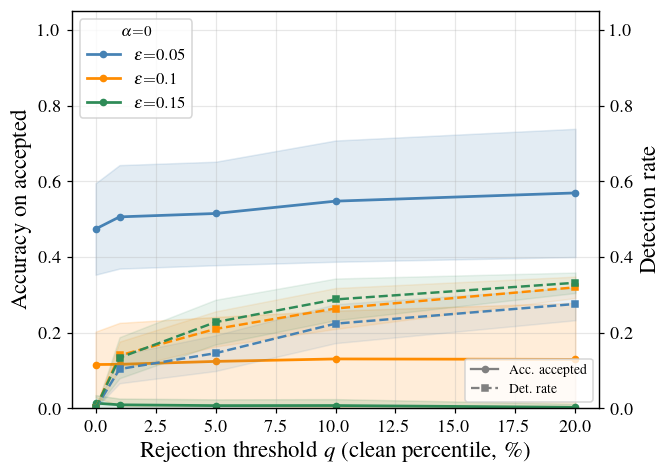

Saved figures/ts/ecg200/d3r10c64/detection/accept_acc_vs_threshold_nat_a0.pdf


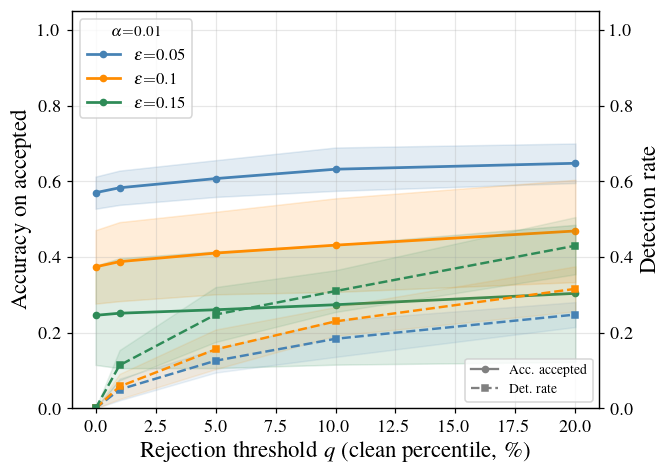

Saved figures/ts/ecg200/d3r10c64/detection/accept_acc_vs_threshold_nat_a001.pdf


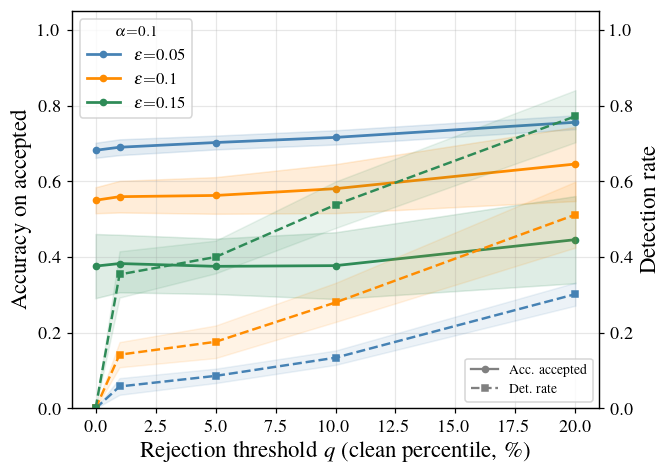

Saved figures/ts/ecg200/d3r10c64/detection/accept_acc_vs_threshold_nat_a01.pdf


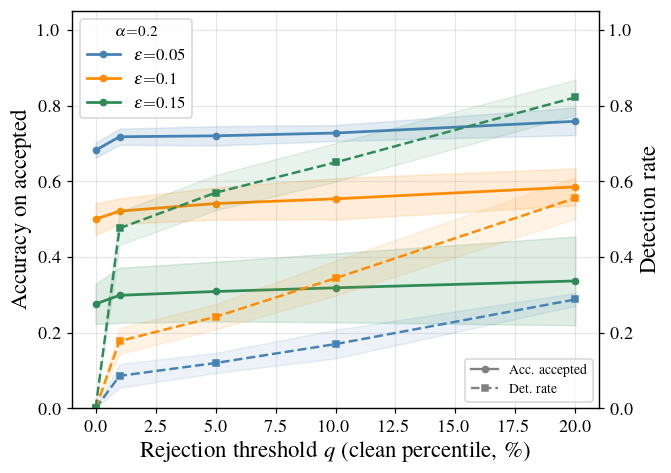

Saved figures/ts/ecg200/d3r10c64/detection/accept_acc_vs_threshold_nat_a02.pdf


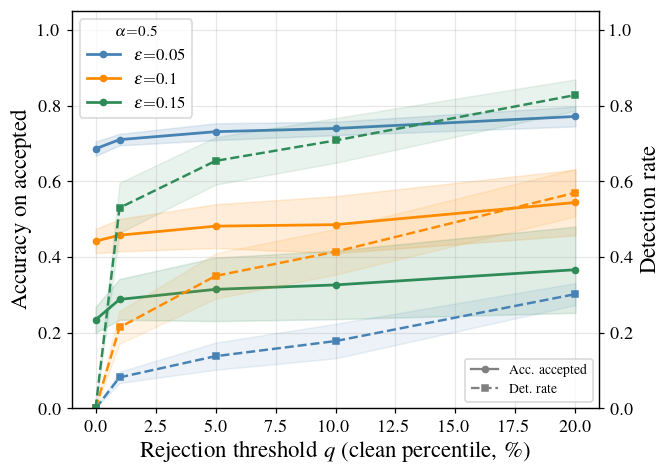

Saved figures/ts/ecg200/d3r10c64/detection/accept_acc_vs_threshold_nat_a05.pdf


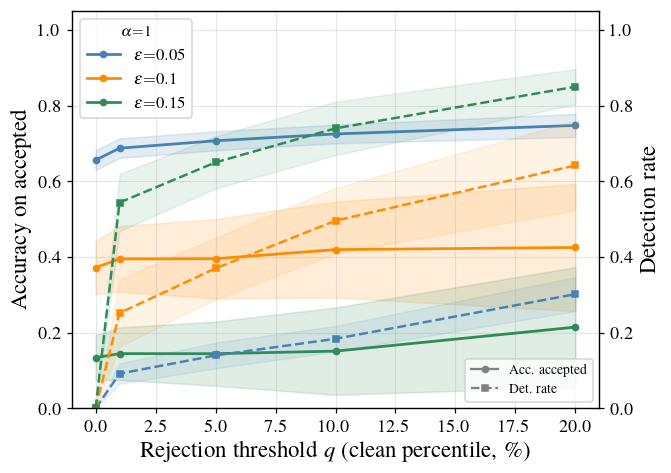

Saved figures/ts/ecg200/d3r10c64/detection/accept_acc_vs_threshold_nat_a1.pdf


In [18]:
from matplotlib.lines import Line2D


def threshold_curve(df, eps, q0_col, tmpl, flip=False):
    """(q, mean, std) vs rejection percentile, with a q=0 anchor (None -> anchor at 0)."""
    qs, mm, ss = [], [], []
    if q0_col is None:
        qs.append(0.0); mm.append(0.0); ss.append(0.0)
    else:
        m, s = ms(df, q0_col)
        if not np.isnan(m):
            qs.append(0.0); mm.append(m); ss.append(s)
    for q in PERCENTILES:
        m, s = ms(df, tmpl.format(q=q, eps=eps), flip=flip)
        if np.isnan(m):
            continue
        qs.append(float(q)); mm.append(m); ss.append(s)
    return np.array(qs), np.array(mm), np.nan_to_num(np.array(ss))


for regime, alpha in models:
    df = sel(EVAL, regime=regime, arch=ARCH, alpha=alpha)
    if df.empty:
        continue
    fig, axl = plt.subplots(figsize=(6.2, 4.4))
    axr = axl.twinx()
    handles = []
    for eps in EPS_LIST:
        c = EPS_COLOR[eps]
        q, m, s = threshold_curve(df, eps, f"uq_adv_acc/{eps}",
                                  "uq_det_err_passed/{q}pct/{eps}", flip=True)
        if len(q):
            (ln,) = axl.plot(q, m, color=c, ls="-", lw=1.8, marker="o", ms=4,
                             label=rf"$\varepsilon{{=}}{bstr(eps)}$")
            axl.fill_between(q, m - s, m + s, color=c, alpha=0.15)
            handles.append(ln)
        q, m, s = threshold_curve(df, eps, None, "uq_detection/{q}pct/{eps}")
        if len(q):
            axr.plot(q, m, color=c, ls="--", lw=1.6, marker="s", ms=4)
            axr.fill_between(q, m - s, m + s, color=c, alpha=0.10)

    axl.set_xlabel(rf"Rejection threshold $q$ (clean percentile, ${PCT}$)")
    axl.set_ylabel("Accuracy on accepted")
    axr.set_ylabel("Detection rate")
    axl.set_ylim(0, 1.05); axr.set_ylim(0, 1.05); axl.grid(True, alpha=0.3)
    leg1 = axl.legend(handles=handles, title=model_label(regime, alpha), loc="upper left")
    axl.add_artist(leg1)
    axl.legend(handles=[Line2D([], [], color="gray", ls="-", marker="o", ms=4,
                               label="Acc. accepted"),
                        Line2D([], [], color="gray", ls="--", marker="s", ms=4,
                               label="Det. rate")],
               fontsize=9, loc="lower right")
    fig.tight_layout()
    tag = f"{regime}_a{alpha_str(alpha).replace('.', '')}"
    save(fig, fig_path("detection", f"accept_acc_vs_threshold_{tag}.pdf", arch=ARCH))

## §2.5  Likelihood purification — the two radii, and what they cost

**§2.5a — under attack.** Purification accuracy against attack budget, one line per purification
radius ($\delta = 0.1$ and $\delta = 0.15$, relative — abs $0.2$ and $0.3$ on legendre), faceted over every model.
The dashed grey reference is undefended `rob/{eps}`, so the vertical gap is the purification lift.
The larger radius searches a bigger ball for a higher-likelihood point: it should recover more
under strong attack, but risks over-moving the input under weak attack.

**§2.5b — the clean-input cost.** `uq_clean_purify_acc/{r}` against $\alpha$, with clean `acc`
as the unpurified reference. A defense that recovers adversarial accuracy but destroys clean
accuracy is not a defense — this is the likelihood-purification counterpart of the Gibbs
clean-cost figure in the MNIST notebook (§2.6c there), and the check matters more here because
purification runs unconditionally, on every input, attacked or not.

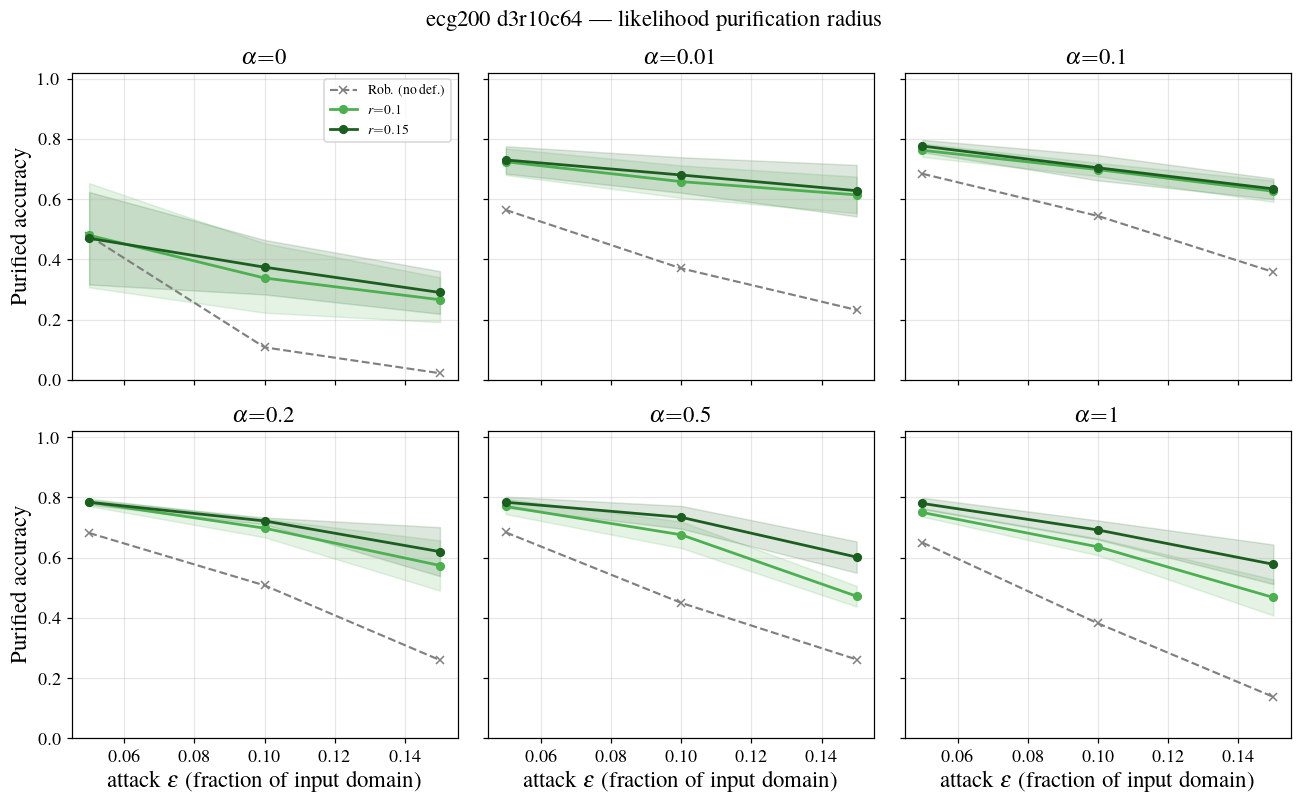

Saved figures/ts/ecg200/d3r10c64/purify_radius/purify_acc_vs_radius.pdf


In [19]:
models = [(r, a) for r, a in MODEL_ORDER if not sel(EVAL, regime=r, arch=ARCH, alpha=a).empty]

ncol = min(len(models), 3)
nrow = int(np.ceil(len(models) / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(4.0 * ncol, 3.7 * nrow),
                         sharey=True, sharex=True, squeeze=False)
for ax, (regime, alpha) in zip(axes.ravel(), models):
    df = sel(EVAL, regime=regime, arch=ARCH, alpha=alpha)
    rob = [ms(df, f"rob/{e}")[0] for e in EPS_LIST]
    ax.plot(EPS_LIST, rob, color="grey", ls="--", lw=1.4, marker="x", ms=5,
            label="Rob. (no def.)")
    for r_ in PURIFY_RADII:
        stats = [ms(df, f"uq_purify_acc/{e}/{r_}") for e in EPS_LIST]
        m, s = map(np.array, zip(*stats))
        if np.all(np.isnan(m)):
            continue
        errline(ax, np.array(EPS_LIST), m, np.nan_to_num(s),
                RADIUS_COLOR.get(r_, "#4CAF50"), rf"$r{{=}}{bstr(r_)}$")
    ax.set_title(model_label(regime, alpha))
    ax.set_ylim(0, 1.02); ax.grid(True, alpha=0.3)
for ax in axes.ravel()[len(models):]:
    ax.axis("off")
for ax in axes[-1, :]:
    ax.set_xlabel(rf"attack $\varepsilon$ ({'absolute' if REPORT_UNIT == 'abs' else 'fraction of input domain'})")
for ax in axes[:, 0]:
    ax.set_ylabel("Purified accuracy")
axes[0, 0].legend(fontsize=9, loc="upper right")
fig.suptitle(f"{DATASET} {ARCH} — likelihood purification radius", fontsize=15)
fig.tight_layout()
save(fig, fig_path("purify_radius", "purify_acc_vs_radius.pdf", arch=ARCH))

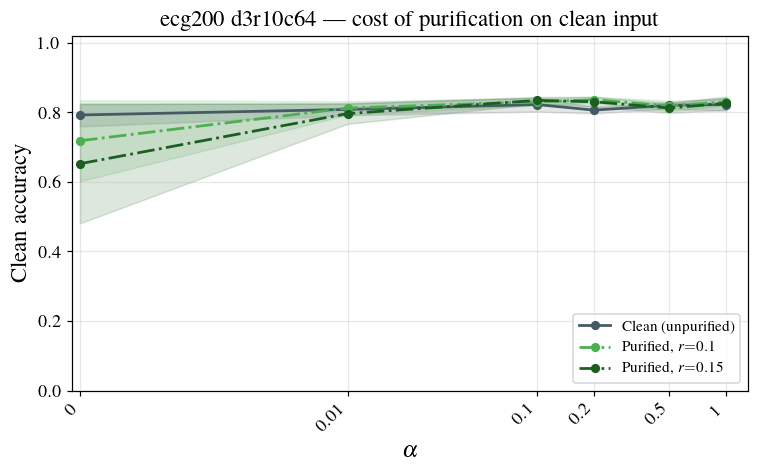

Saved figures/ts/ecg200/d3r10c64/purify_radius/purify_clean_cost.pdf


In [20]:
fig, ax = plt.subplots(figsize=(7, 4.4))
pts = [(a, *ms(sel(EVAL, regime="nat", arch=ARCH, alpha=a), "acc")) for a in NAT_ALPHAS]
pts = [(a, m, s) for a, m, s in pts if not np.isnan(m)]
if pts:
    a, m, s = map(np.array, zip(*pts))
    errline(ax, a, m, s, "#455A64", "Clean (unpurified)", ls="-")
for r_ in PURIFY_RADII:
    pts = [(a, *ms(sel(EVAL, regime="nat", arch=ARCH, alpha=a), f"uq_clean_purify_acc/{r_}"))
           for a in NAT_ALPHAS]
    pts = [(a, m, s) for a, m, s in pts if not np.isnan(m)]
    if not pts:
        continue
    a, m, s = map(np.array, zip(*pts))
    errline(ax, a, m, s, RADIUS_COLOR.get(r_, "#4CAF50"), rf"Purified, $r{{=}}{bstr(r_)}$", ls="-.")

setup_alpha_axis(ax)
ax.set_ylabel("Clean accuracy"); ax.set_ylim(0, 1.02); ax.grid(True, alpha=0.3)
ax.set_title(f"{DATASET} {ARCH} — cost of purification on clean input")
ax.legend(fontsize=10, loc="lower right")
fig.tight_layout()
save(fig, fig_path("purify_radius", "purify_clean_cost.pdf", arch=ARCH))

## §2.6  Gibbs purification against itself

Gibbs purification is **attack-radius agnostic**: its `step_delta_rel` is a *per-sweep* $L_\infty$
move that re-centres each sweep, so strength is controlled by the sweep count $k$ alone and
results are keyed by $k$, never by a radius. The $k=0$ anchor is the **undefended** accuracy
measured on the *same* subsample, so the $k{=}0 \to k{>}0$ lift is paired.

**`gibbs_data.csv` does not exist for these sweeps**, so the three figures below are skipped.
To produce it, run for every run dir listed in §0.1:

```
python analysis/gibbs.py <sweep_dir> --sweeps 1,3,6 --n-eval 250
```

then re-run this notebook — the cell fills in on its own.

In [21]:
if not HAVE_GIBBS:
    print("no gibbs_data.csv under this dataset — §2.6 skipped "
          "(see the analysis/gibbs.py command above)")
else:
    gmodels = [(r, a) for r, a in MODEL_ORDER
               if not sel(GIBBS, regime=r, arch=ARCH, alpha=a).empty]

    # (a) one line per model at the headline epsilon
    fig, ax = plt.subplots(figsize=(7, 4.6))
    for regime, alpha in gmodels:
        k, m, s = gibbs_curve(sel(GIBBS, regime=regime, arch=ARCH, alpha=alpha), EPS_MAIN)
        errline(ax, k, m, s, MODEL_COLOR[(regime, alpha)], model_label(regime, alpha))
    ax.set_xticks([0] + GIBBS_KS)
    ax.set_xlabel("Gibbs sweeps $k$   ($k=0$: undefended, same subsample)")
    ax.set_ylabel("Accuracy under attack")
    ax.set_ylim(0, 1.02); ax.grid(True, alpha=0.3)
    ax.set_title(rf"{DATASET} {ARCH} — Gibbs purification ($\varepsilon={EPS_MAIN_D}$, "
                 rf"$n_{{\mathrm{{eval}}}}={GIBBS_N_EVAL}$)")
    ax.legend(fontsize=9, ncol=2, loc="best")
    fig.tight_layout()
    save(fig, fig_path("gibbs", "gibbs_alpha_vs_k.pdf", arch=ARCH))

    # (b) one panel per epsilon
    fig, axes = plt.subplots(1, len(EPS_LIST), figsize=(4.7 * len(EPS_LIST), 4.3),
                             sharey=True, squeeze=False)
    for ax, eps in zip(axes[0], EPS_LIST):
        for regime, alpha in gmodels:
            k, m, s = gibbs_curve(sel(GIBBS, regime=regime, arch=ARCH, alpha=alpha), eps)
            errline(ax, k, m, s, MODEL_COLOR[(regime, alpha)], model_label(regime, alpha))
        ax.set_title(rf"$\varepsilon={bstr(eps)}$")
        ax.set_xticks([0] + GIBBS_KS); ax.set_xlabel("Gibbs sweeps $k$")
        ax.set_ylim(0, 1.02); ax.grid(True, alpha=0.3)
    axes[0][0].set_ylabel("Accuracy under attack")
    axes[0][0].legend(fontsize=8, ncol=2, loc="best")
    fig.suptitle(rf"{DATASET} {ARCH} — Gibbs purification vs $k$ "
                 rf"($n_{{\mathrm{{eval}}}}={GIBBS_N_EVAL}$)", fontsize=15)
    fig.tight_layout()
    save(fig, fig_path("gibbs", "gibbs_alpha_vs_k_by_eps.pdf", arch=ARCH))

    # (c) the clean-input cost
    fig, ax = plt.subplots(figsize=(7, 4.4))
    for regime, alpha in gmodels:
        k, m, s = gibbs_curve(sel(GIBBS, regime=regime, arch=ARCH, alpha=alpha), eps=None)
        errline(ax, k, m, s, MODEL_COLOR[(regime, alpha)], model_label(regime, alpha))
    ax.set_xticks([0] + GIBBS_KS)
    ax.set_xlabel("Gibbs sweeps $k$   ($k=0$: unpurified clean input)")
    ax.set_ylabel("Clean accuracy")
    ax.grid(True, alpha=0.3)
    ax.set_title(rf"{DATASET} {ARCH} — cost of Gibbs purification on clean input "
                 rf"($n_{{\mathrm{{eval}}}}={GIBBS_N_EVAL}$)")
    ax.legend(fontsize=9, ncol=2, loc="best")
    fig.tight_layout()
    save(fig, fig_path("gibbs", "gibbs_clean_cost.pdf", arch=ARCH))

no gibbs_data.csv under this dataset — §2.6 skipped (see the analysis/gibbs.py command above)


## §2.7  Model-comparison tables

Two tables for the committed bond dimension, each as booktabs `.tex`
(needs `\usepackage{booktabs,multirow}`) and an aligned `.txt` preview. Best per column in
**bold** (`*` in the `.txt`); all metrics are higher-is-better.

- **`model_comparison_eps{EPS_MAIN}`** — the compact headline table: one row per model, one
  column per metric, at a single $\varepsilon$.
- **`model_comparison`** — the full table: metric rows nested under each model, one column per
  $\varepsilon$.

In [22]:
# (tex header, txt header, source, column template, flip)
TABLE_METRICS = [
    ("Clean",                                    "Clean",        EVAL,  "acc",                                       False),
    (r"Rob.",                                    "Rob.",         EVAL,  "rob/{eps}",                                 False),
]
for r_ in PURIFY_RADII:
    TABLE_METRICS.append((rf"Purif.\ (lk., $r{{=}}{bstr(r_)}$)", f"Purif lk r{bstr(r_)}",
                          EVAL, f"uq_purify_acc/{{eps}}/{r_}", False))
if HAVE_GIBBS:
    TABLE_METRICS.append((rf"Purif.\ (Gibbs, $k{{=}}{GIBBS_K}$)", f"Purif Gk{GIBBS_K}",
                          GIBBS, f"gibbs_purify_acc/{{eps}}/{GIBBS_K}", False))
TABLE_METRICS += [
    (r"Det.\ rate ($q{=}10\%$)",                 "Det rate",     EVAL,  f"uq_detection/{DET_PCT}/{{eps}}",           False),
    (r"Acc.\ passed ($q{=}10\%$)",               "Acc passed",   EVAL,  f"uq_det_err_passed/{DET_PCT}/{{eps}}",      True),
]

TABLE_MODELS = [(r, a) for r, a in MODEL_ORDER
                if not sel(EVAL, regime=r, arch=ARCH, alpha=a).empty]
CAPTION_NOTE = (rf"{DATASET}, Legendre $d{{=}}3$, $r{{=}}{BOND_DIM}$, {N_SEEDS} seeds "
                rf"(mean $\pm$ 1 std)."
                + (rf" Gibbs uses an $n_{{\mathrm{{eval}}}}={GIBBS_N_EVAL}$ subsample; all other "
                   rf"columns use the full test split." if HAVE_GIBBS else
                   r" All columns use the full test split."))


def cellstat(regime, alpha, src, tmpl, flip, eps):
    return ms(sel(src, regime=regime, arch=ARCH, alpha=alpha), tmpl.format(eps=eps), flip)


# ---- compact table: models x metrics, single epsilon ----------------------
grid = [[cellstat(r, a, src, tmpl, flip, EPS_MAIN)
         for _, _, src, tmpl, flip in TABLE_METRICS] for r, a in TABLE_MODELS]
best = [best_index([grid[i][j][0] for i in range(len(TABLE_MODELS))])
        for j in range(len(TABLE_METRICS))]

L = [r"\begin{table}[htbp]", r"  \centering", r"  \small",
     r"  \begin{tabular}{@{}l" + "r" * len(TABLE_METRICS) + r"@{}}", r"    \toprule",
     "    Model & " + " & ".join(h for h, *_ in TABLE_METRICS) + r" \\", r"    \midrule"]
for i, (r_, a) in enumerate(TABLE_MODELS):
    L.append(f"    {model_label(r_, a)} & " +
             " & ".join(tex_cell(m, s, bold=(best[j] == i))
                        for j, (m, s) in enumerate(grid[i])) + r" \\")
L += [r"    \bottomrule", r"  \end{tabular}",
      rf"  \caption{{Defenses at $\varepsilon={EPS_MAIN_D}$, $q{{=}}10\%$. {CAPTION_NOTE}}}",
      rf"  \label{{tab:{DATASET}_models_r{BOND_DIM}_eps{EPS_MAIN_D}}}", r"\end{table}"]
fig_path("tables", f"model_comparison_eps{EPS_MAIN_D}.tex", arch=ARCH).write_text("\n".join(L) + "\n")

W = 17
hdr = f"{'Model':<14}" + "".join(f"{h2:<{W}}" for _, h2, *_ in TABLE_METRICS)
P = [f"{DATASET} {ARCH} — defenses at eps={EPS_MAIN_D}, q=10% "
     f"(mean±std over {N_SEEDS} seeds); * = best per column", hdr, "-" * len(hdr)]
for i, (r_, a) in enumerate(TABLE_MODELS):
    P.append(f"{model_label(r_, a, tex=False):<14}" +
             "".join(f"{txt_cell(m, s, best=(best[j] == i)):<{W}}"
                     for j, (m, s) in enumerate(grid[i])))
fig_path("tables", f"model_comparison_eps{EPS_MAIN_D}.txt", arch=ARCH).write_text("\n".join(P) + "\n")
print("\n".join(P))
print()

ecg200 d3r10c64 — defenses at eps=0.1, q=10% (mean±std over 10 seeds); * = best per column
Model         Clean            Rob.             Purif lk r0.1    Purif lk r0.15   Det rate         Acc passed       
--------------------------------------------------------------------------------------------------------------------
a=0           0.792±0.033      0.108±0.085      0.338±0.115      0.374±0.090      0.264±0.054      0.131±0.128      
a=0.01        0.808±0.017      0.370±0.086      0.658±0.054      0.680±0.059      0.230±0.038      0.431±0.124      
a=0.1         0.822±0.020      0.544±0.023*     0.698±0.022      0.704±0.042      0.280±0.052      0.581±0.065*     
a=0.2         0.806±0.010      0.508±0.030      0.698±0.030*     0.722±0.011      0.344±0.046      0.554±0.054      
a=0.5         0.820±0.009      0.450±0.033      0.676±0.044      0.734±0.038*     0.414±0.060      0.485±0.075      
a=1           0.822±0.018*     0.382±0.077      0.636±0.028      0.692±0.032      0.496±0.

In [23]:
# ---- full table: (model x metric) rows, epsilon columns -------------------
data = [[[cellstat(r_, a, src, tmpl, flip, e) for e in EPS_LIST]
         for _, _, src, tmpl, flip in TABLE_METRICS] for r_, a in TABLE_MODELS]
best = [[best_index([data[i][j][e][0] for i in range(len(TABLE_MODELS))])
         for e in range(len(EPS_LIST))] for j in range(len(TABLE_METRICS))]

n_m = len(TABLE_METRICS)
L = [r"\begin{table}[htbp]", r"  \centering", r"  \small",
     r"  \begin{tabular}{@{}ll" + "r" * len(EPS_LIST) + r"@{}}", r"    \toprule",
     "    Model & Metric & " + " & ".join(rf"$\varepsilon={bstr(e)}$" for e in EPS_LIST) + r" \\",
     r"    \midrule"]
for i, (r_, a) in enumerate(TABLE_MODELS):
    for j, (h, *_rest) in enumerate(TABLE_METRICS):
        first = f"\\multirow{{{n_m}}}{{*}}{{{model_label(r_, a)}}}" if j == 0 else ""
        cells = [tex_cell(*data[i][j][e], bold=(best[j][e] == i)) for e in range(len(EPS_LIST))]
        L.append(f"    {first} & {h} & " + " & ".join(cells) + r" \\")
    if i < len(TABLE_MODELS) - 1:
        L.append(r"    \cmidrule(lr){1-%d}" % (2 + len(EPS_LIST)))
L += [r"    \bottomrule", r"  \end{tabular}",
      rf"  \caption{{Defenses across attack budgets, $q{{=}}10\%$, likelihood-purification "
      rf"radii as labelled. {CAPTION_NOTE}}}",
      rf"  \label{{tab:{DATASET}_models_r{BOND_DIM}}}", r"\end{table}"]
fig_path("tables", "model_comparison.tex", arch=ARCH).write_text("\n".join(L) + "\n")

W = 17
hdr = f"{'Model':<14}{'Metric':<18}" + "".join(f"{'eps=' + str(e):<{W}}" for e in EPS_LIST)
P = [f"{DATASET} {ARCH} — defenses vs attack budget, q=10% "
     f"(mean±std over {N_SEEDS} seeds); * = best per column", hdr, "-" * len(hdr)]
for i, (r_, a) in enumerate(TABLE_MODELS):
    for j, (_, h2, *_rest) in enumerate(TABLE_METRICS):
        lab = model_label(r_, a, tex=False) if j == 0 else ""
        P.append(f"{lab:<14}{h2:<18}" +
                 "".join(f"{txt_cell(*data[i][j][e], best=(best[j][e] == i)):<{W}}"
                         for e in range(len(EPS_LIST))))
    P.append("-" * len(hdr))
fig_path("tables", "model_comparison.txt", arch=ARCH).write_text("\n".join(P) + "\n")
print("\n".join(P))

ecg200 d3r10c64 — defenses vs attack budget, q=10% (mean±std over 10 seeds); * = best per column
Model         Metric            eps=0.05         eps=0.1          eps=0.15         
-----------------------------------------------------------------------------------
a=0           Clean             0.792±0.033      0.792±0.033      0.792±0.033      
              Rob.              0.478±0.121      0.108±0.085      0.022±0.033      
              Purif lk r0.1     0.480±0.173      0.338±0.115      0.266±0.074      
              Purif lk r0.15    0.470±0.154      0.374±0.090      0.290±0.071      
              Det rate          0.224±0.051*     0.264±0.054      0.288±0.055      
              Acc passed        0.548±0.160      0.131±0.128      0.008±0.017      
-----------------------------------------------------------------------------------
a=0.01        Clean             0.808±0.017      0.808±0.017      0.808±0.017      
              Rob.              0.564±0.040      0.370±0.086   

## §2.8  Adaptive (joint) attack — difference table

$\Delta = $ joint $-$ standard, one table per $\varepsilon$. The joint attack is
detector-aware: it maximises classification loss *while* keeping $\log p(x)$ high, so a negative
$\Delta$ means the adaptive attacker is stronger (lower accuracy, or lower detection rate). This
is the honesty check on §2.4 — a detector that only works against a detector-unaware attacker is
not a defense.

`Det.` uses the detection **rate** rather than error-among-detected, which goes `NaN` once the
joint attack fully evades the detector.

In [24]:
# (joint template, standard template, tex label, txt label)
JN_METRICS = [
    ("uq_joint_adv_acc/{eps}", "uq_adv_acc/{eps}", r"Rob.", "Rob."),
    (f"uq_joint_purify_acc/{{eps}}/{PURIFY_RADIUS}", f"uq_purify_acc/{{eps}}/{PURIFY_RADIUS}",
     r"Purif.\ (lk.)", "Purif lk"),
    (f"uq_joint_detection/{DET_PCT}/{{eps}}", f"uq_detection/{DET_PCT}/{{eps}}",
     r"Det.\ rate ($q{=}10\%$)", "Det rate"),
    (f"uq_joint_det_err_passed/{DET_PCT}/{{eps}}", f"uq_det_err_passed/{DET_PCT}/{{eps}}",
     r"Accept.\ err ($q{=}10\%$)", "Accept err"),
]


def delta(df, jcol, ncol):
    """Paired per-seed difference (joint - standard); (nan, nan) if either column is absent."""
    if df.empty or jcol not in df.columns or ncol not in df.columns:
        return float("nan"), float("nan")
    d = (pd.to_numeric(df[jcol], errors="coerce").to_numpy()
         - pd.to_numeric(df[ncol], errors="coerce").to_numpy())
    d = d[np.isfinite(d)]
    if len(d) == 0:
        return float("nan"), float("nan")
    return float(d.mean()), float(d.std() if len(d) > 1 else 0.0)


dfs = [(model_label(r, a), model_label(r, a, tex=False),
        sel(EVAL, regime=r, arch=ARCH, alpha=a)) for r, a in TABLE_MODELS]
plain_all = []
for eps in EPS_LIST:
    L = [r"\begin{table}[htbp]", r"  \centering", r"  \small",
         r"  \begin{tabular}{@{}l" + "c" * len(dfs) + r"@{}}", r"    \toprule",
         "    Metric & " + " & ".join(t for t, _, _ in dfs) + r" \\", r"    \midrule"]
    plain = [f"=== eps={bstr(eps)} ===",
             f"{'Metric':<14}" + "".join(f"{p:<18}" for _, p, _ in dfs)]
    for jt, nt, tlab, plab in JN_METRICS:
        cells = [delta(df, jt.format(eps=eps), nt.format(eps=eps)) for _, _, df in dfs]
        L.append(f"    {tlab} & " +
                 " & ".join(tex_cell(m, s, signed=True) for m, s in cells) + r" \\")
        plain.append(f"{plab:<14}" +
                     "".join(f"{txt_cell(m, s, signed=True):<18}" for m, s in cells))
    L += [r"    \bottomrule", r"  \end{tabular}",
          rf"  \caption{{Joint (detector-aware) minus standard attack at $\varepsilon={bstr(eps)}$, "
          rf"$q{{=}}10\%$. Negative $\Rightarrow$ the joint attack is stronger. {CAPTION_NOTE}}}",
          rf"  \label{{tab:{DATASET}_joint_r{BOND_DIM}_eps{bstr(eps)}}}", r"\end{table}"]
    fig_path("tables", f"joint_vs_normal_eps{bstr(eps)}.tex", arch=ARCH).write_text("\n".join(L) + "\n")
    plain_all += plain + [""]

fig_path("tables", "joint_vs_normal.txt", arch=ARCH).write_text("\n".join(plain_all) + "\n")
print(f"Saved joint_vs_normal_eps{{{','.join(bstr(e) for e in EPS_LIST)}}}.tex "
      f"and joint_vs_normal.txt\n")
print("\n".join(plain_all))

Saved joint_vs_normal_eps{0.05,0.1,0.15}.tex and joint_vs_normal.txt

=== eps=0.05 ===
Metric        a=0               a=0.01            a=0.1             a=0.2             a=0.5             a=1               
Rob.          +0.146±0.054      +0.150±0.041      +0.052±0.030      +0.096±0.023      +0.128±0.022      +0.158±0.026      
Purif lk      +0.046±0.028      -0.000±0.032      +0.018±0.023      +0.006±0.016      +0.022±0.021      +0.026±0.025      
Det rate      -0.188±0.051      -0.178±0.044      -0.134±0.018      -0.170±0.036      -0.178±0.043      -0.184±0.032      
Accept err    -0.076±0.082      -0.088±0.062      -0.018±0.029      -0.050±0.026      -0.074±0.028      -0.089±0.025      

=== eps=0.1 ===
Metric        a=0               a=0.01            a=0.1             a=0.2             a=0.5             a=1               
Rob.          +0.248±0.088      +0.298±0.124      +0.154±0.049      +0.210±0.038      +0.340±0.036      +0.422±0.070      
Purif lk      +0.040±0.069      +0.

---
## Where everything landed

```
figures/ts/{DATASET}/
  compare/
    dataset/  traces_by_class.pdf
    bonddim/  metric_vs_bonddim.pdf · alpha_curve_by_bonddim.pdf
              accept_curve_by_bonddim.pdf · nll_vs_bonddim.pdf
    tables/   bonddim_summary.{tex,txt}
  {ARCH}/
    alpha/          alpha_curve_accuracy.pdf · alpha_curve_nll.pdf
    robustness/     defense_comparison_eps{0.05,0.1,0.15}.pdf
    detection/      accept_acc_vs_passed_ratio.pdf
                    accept_acc_vs_threshold_{nat_a0,...}.pdf
    purify_radius/  purify_acc_vs_radius.pdf · purify_clean_cost.pdf
    gibbs/          (empty until analysis/gibbs.py is run)
    tables/         model_comparison.{tex,txt}
                    model_comparison_eps{EPS_MAIN}.{tex,txt}
                    joint_vs_normal_eps{0.05,0.1,0.15}.tex · joint_vs_normal.txt
```

To regenerate at another bond dimension set `BOND_DIM` in §0.2 and re-run from there; to switch
dataset set `DATASET` in §0.1 and re-run from the top.